# CAPTCHA GAN Training
Adapted from PyTorch DCGAN Tutorial: https://docs.pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

In [1]:
#%matplotlib inline
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [2]:
# Root directory for dataset
dataroot = "train"

# Number of channels in the training images. For color images this is 3
nc = 3

# Size of z latent vector (i.e. size of generator input)
nz = 128

# Size of feature maps in generator
ngf = 64

# Size of feature maps in discriminator
ndf = 64

# Beta1 hyperparameter for Adam optimizers
beta1 = 0.5

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1

# Create Datasets
Target resolution is 256x40 px.
Thus, resize + crop / pad all training data to this size as well.

In [3]:
import os
import random
import numpy as np
import cv2
import torch
from torch.utils.data import DataLoader
from torchvision import datasets as dset, transforms
import torchvision.transforms.functional as TF
from PIL import Image, ImageOps


class ResizePadToWidth:
    def __init__(self, target_height=80, target_width=512, grayscale=True, pad_color=255, augment=False):
        self.target_height = target_height
        self.target_width = target_width
        self.grayscale = grayscale
        self.pad_color = pad_color
        self.augment = augment

    def __call__(self, img):
        # If img is PIL.Image, convert to OpenCV NumPy array
        if isinstance(img, Image.Image):
            img = np.array(img)
            # Convert RGB to BGR for OpenCV
            if not self.grayscale and img.ndim == 3:
                img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

        H, W = img.shape[:2]

        # Resize keeping aspect ratio
        if H != self.target_height:
            new_W = int(W * (self.target_height / float(H)))
            img = cv2.resize(img, (new_W, self.target_height), interpolation=cv2.INTER_AREA)
            H, W = img.shape[:2]

        # Crop if too wide
        if W > self.target_width:
            if self.augment:
                left = random.randint(0, W - self.target_width)
            else:
                left = (W - self.target_width) // 2
            img = img[:, left:left + self.target_width]
            W = self.target_width

        # Pad if too narrow 
        pad_left = (self.target_width - W) // 2
        pad_right = self.target_width - W - pad_left
        if self.augment and self.target_width - W > 0:
            shift = random.randint(-int(0.15 * (self.target_width - W)), int(0.15 * (self.target_width - W)))
            pad_left = max(0, min(self.target_width - W, pad_left + shift))
            pad_right = self.target_width - W - pad_left

        if self.grayscale:
            if img.ndim == 3:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.copyMakeBorder(img, 0, 0, pad_left, pad_right, borderType=cv2.BORDER_CONSTANT, value=self.pad_color)
        else:
            if img.ndim == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            img = cv2.copyMakeBorder(img, 0, 0, pad_left, pad_right, borderType=cv2.BORDER_CONSTANT, value=[self.pad_color]*3)

        # To tensor in [-1,1]
        img = img.astype(np.float32) / 255.0
        img = (img - 0.5) / 0.5

        if self.grayscale:
            tensor = torch.from_numpy(img).unsqueeze(0)  # [1,H,W]
        else:
            tensor = torch.from_numpy(np.transpose(img, (2,0,1)))  # [3,H,W]

        return tensor


In [4]:
# We can use an image folder dataset the way we have it setup.
# Create the dataset
dataset = dset.ImageFolder(
    root=dataroot,
    transform=ResizePadToWidth(target_height=40,
                                  target_width=256,
                                  grayscale=False,   # change to False for RGB
                                  pad_color=255,    # white padding
                                  augment=True)
)

# Create DataLoader
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)


# Prepare GPU

In [5]:
# Decide which device we want to run on
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")
print(device)

cuda:0


# View Dataset

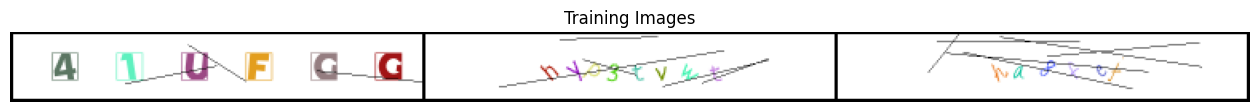

In [6]:
# Plot some training images
real_batch = next(iter(dataloader))
plt.figure(figsize=(16,16))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:3], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

# Weight Init

In [8]:
# custom weights initialization called on ``netG`` and ``netD``
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# Generator

In [9]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, nz=128, ngf=64, nc=3):
        super().__init__()

        self.main = nn.Sequential(
            # 1x1 → 5x16
            nn.ConvTranspose2d(nz, ngf*16, kernel_size=(5,16), stride=1, padding=0, bias=False),
            nn.BatchNorm2d(ngf*16),
            nn.ReLU(True),

            # 5x16 → 10x32
            nn.ConvTranspose2d(ngf*16, ngf*8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),

            # 10x32 → 20x64
            nn.ConvTranspose2d(ngf*8, ngf*4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),

            # 20x64 → 40x128
            nn.ConvTranspose2d(ngf*4, ngf*2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),

            # 40x128 → 40x256 (double width only)
            nn.ConvTranspose2d(ngf*2, ngf, kernel_size=(3,4), stride=(1,2), padding=(1,1), bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            # final: 40×256 → output RGB
            nn.ConvTranspose2d(ngf, nc, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.main(z)

In [10]:
# Create the generator
netG = Generator().to(device)

# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpu > 1):
    netG = nn.DataParallel(netG, list(range(ngpu)))

# Apply the ``weights_init`` function to randomly initialize all weights
#  to ``mean=0``, ``stdev=0.02``.
netG.apply(weights_init)

# Print the model
print(netG)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(128, 1024, kernel_size=(5, 16), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(128, 64, kernel_size=(3, 4), stride=(1, 2), padding=(1, 1), bias=False)
    (13): Batch

# Discriminator

In [11]:
class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64):
        super().__init__()
        self.main = nn.Sequential(
            # 40x256 → 20x128
            nn.Conv2d(nc, ndf, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 20x128 → 10x64
            nn.Conv2d(ndf, ndf*2, 4, 2, 1),
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2, inplace=True),

            # 10x64 → 5x32
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1),
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2, inplace=True),

            # 5x32 → 1x1
            nn.Conv2d(ndf*4, 1, kernel_size=(5,32), stride=1, padding=0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x).view(-1)  # [batch]

In [12]:
# Create the Discriminator
netD = Discriminator().to(device)

# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpu > 1):
    netD = nn.DataParallel(netD, list(range(ngpu)))

# Apply the ``weights_init`` function to randomly initialize all weights
# like this: ``to mean=0, stdev=0.2``.
netD.apply(weights_init)

# Print the model
print(netD)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 1, kernel_size=(5, 32), stride=(1, 1))
    (9): Sigmoid()
  )
)


# Training

In [13]:
# Initialize the ``BCELoss`` function
criterion = nn.BCELoss()

# Create batch of latent vectors that we will use to visualize
#  the progression of the generator
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Establish convention for real and fake labels during training
real_label = 1.0
fake_label = 0.0

# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

Starting Training Loop...
[0/200][0/157]	Loss_D: 0.3244	Loss_G: 4.2705	D(x): 0.7630	D(G(z)): 0.0040 / 0.0498
[0/200][50/157]	Loss_D: 0.1093	Loss_G: 4.9421	D(x): 0.9487	D(G(z)): 0.0470 / 0.0196
[0/200][100/157]	Loss_D: 0.1735	Loss_G: 4.4676	D(x): 0.8683	D(G(z)): 0.0135 / 0.0498
[0/200][150/157]	Loss_D: 0.2331	Loss_G: 5.0264	D(x): 0.9916	D(G(z)): 0.1685 / 0.0183


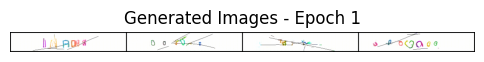

[1/200][0/157]	Loss_D: 0.1343	Loss_G: 4.4121	D(x): 0.9922	D(G(z)): 0.1008 / 0.0502
[1/200][50/157]	Loss_D: 0.1587	Loss_G: 4.4546	D(x): 0.9047	D(G(z)): 0.0439 / 0.0354
[1/200][100/157]	Loss_D: 0.6105	Loss_G: 2.6441	D(x): 0.6262	D(G(z)): 0.0014 / 0.2196
[1/200][150/157]	Loss_D: 0.1441	Loss_G: 4.3291	D(x): 0.9568	D(G(z)): 0.0856 / 0.0588


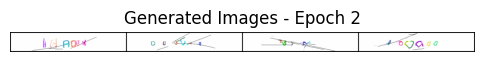

[2/200][0/157]	Loss_D: 0.5224	Loss_G: 4.5393	D(x): 0.9892	D(G(z)): 0.3034 / 0.0281
[2/200][50/157]	Loss_D: 0.0423	Loss_G: 6.7477	D(x): 0.9711	D(G(z)): 0.0111 / 0.0063
[2/200][100/157]	Loss_D: 0.1121	Loss_G: 5.4507	D(x): 0.9973	D(G(z)): 0.0840 / 0.0186
[2/200][150/157]	Loss_D: 0.1049	Loss_G: 4.6720	D(x): 0.9222	D(G(z)): 0.0141 / 0.0314


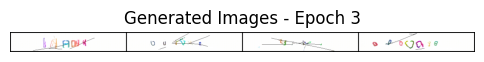

[3/200][0/157]	Loss_D: 0.1985	Loss_G: 3.6900	D(x): 0.8496	D(G(z)): 0.0025 / 0.0847
[3/200][50/157]	Loss_D: 0.0737	Loss_G: 5.9889	D(x): 0.9714	D(G(z)): 0.0354 / 0.0079
[3/200][100/157]	Loss_D: 0.2780	Loss_G: 6.0628	D(x): 0.9953	D(G(z)): 0.1806 / 0.0102
[3/200][150/157]	Loss_D: 0.2323	Loss_G: 3.3171	D(x): 0.8519	D(G(z)): 0.0247 / 0.0886


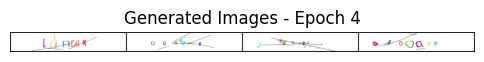

[4/200][0/157]	Loss_D: 2.1983	Loss_G: 10.1465	D(x): 0.9998	D(G(z)): 0.7441 / 0.0008
[4/200][50/157]	Loss_D: 0.2072	Loss_G: 3.5597	D(x): 0.8546	D(G(z)): 0.0209 / 0.0903
[4/200][100/157]	Loss_D: 0.3593	Loss_G: 9.4702	D(x): 0.9848	D(G(z)): 0.2459 / 0.0003
[4/200][150/157]	Loss_D: 0.0653	Loss_G: 4.2365	D(x): 0.9902	D(G(z)): 0.0503 / 0.0481


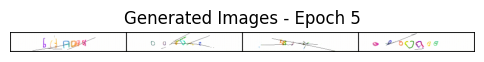

[5/200][0/157]	Loss_D: 0.0784	Loss_G: 5.4269	D(x): 0.9710	D(G(z)): 0.0417 / 0.0129
[5/200][50/157]	Loss_D: 0.0849	Loss_G: 4.2496	D(x): 0.9692	D(G(z)): 0.0496 / 0.0475
[5/200][100/157]	Loss_D: 0.1095	Loss_G: 5.2433	D(x): 0.9306	D(G(z)): 0.0314 / 0.0194
[5/200][150/157]	Loss_D: 0.0331	Loss_G: 5.8907	D(x): 0.9869	D(G(z)): 0.0189 / 0.0183


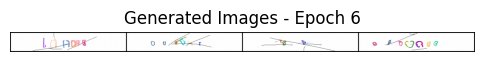

[6/200][0/157]	Loss_D: 0.1151	Loss_G: 4.5825	D(x): 0.9106	D(G(z)): 0.0099 / 0.0372
[6/200][50/157]	Loss_D: 0.1277	Loss_G: 3.6849	D(x): 0.9963	D(G(z)): 0.0602 / 0.0700
[6/200][100/157]	Loss_D: 0.6601	Loss_G: 6.6963	D(x): 0.9929	D(G(z)): 0.3930 / 0.0052
[6/200][150/157]	Loss_D: 0.1334	Loss_G: 4.8939	D(x): 0.9926	D(G(z)): 0.1012 / 0.0337


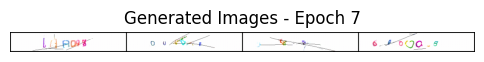

[7/200][0/157]	Loss_D: 0.0639	Loss_G: 4.8350	D(x): 0.9725	D(G(z)): 0.0319 / 0.0396
[7/200][50/157]	Loss_D: 0.0899	Loss_G: 4.8375	D(x): 0.9405	D(G(z)): 0.0220 / 0.0231
[7/200][100/157]	Loss_D: 0.2941	Loss_G: 2.0617	D(x): 0.7809	D(G(z)): 0.0043 / 0.3179
[7/200][150/157]	Loss_D: 0.1672	Loss_G: 2.8873	D(x): 0.8870	D(G(z)): 0.0253 / 0.1543


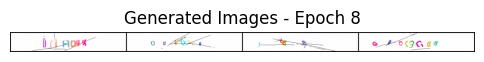

[8/200][0/157]	Loss_D: 0.0734	Loss_G: 4.7225	D(x): 0.9432	D(G(z)): 0.0112 / 0.0533
[8/200][50/157]	Loss_D: 0.0355	Loss_G: 4.4350	D(x): 0.9927	D(G(z)): 0.0270 / 0.0483
[8/200][100/157]	Loss_D: 0.4799	Loss_G: 1.5148	D(x): 0.7785	D(G(z)): 0.1474 / 0.3262
[8/200][150/157]	Loss_D: 0.3279	Loss_G: 2.9674	D(x): 0.7732	D(G(z)): 0.0041 / 0.1698


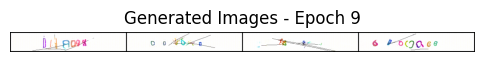

[9/200][0/157]	Loss_D: 0.4077	Loss_G: 4.8646	D(x): 0.9867	D(G(z)): 0.2737 / 0.0247
[9/200][50/157]	Loss_D: 0.1530	Loss_G: 5.3894	D(x): 0.9683	D(G(z)): 0.0987 / 0.0241
[9/200][100/157]	Loss_D: 0.2138	Loss_G: 3.8080	D(x): 0.9590	D(G(z)): 0.1408 / 0.0663
[9/200][150/157]	Loss_D: 0.1265	Loss_G: 4.5042	D(x): 0.9836	D(G(z)): 0.0915 / 0.0449


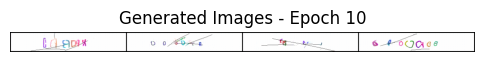

[10/200][0/157]	Loss_D: 0.9683	Loss_G: 9.3568	D(x): 0.9985	D(G(z)): 0.4980 / 0.0006
[10/200][50/157]	Loss_D: 0.0591	Loss_G: 3.2346	D(x): 0.9716	D(G(z)): 0.0279 / 0.1088
[10/200][100/157]	Loss_D: 0.0862	Loss_G: 4.5161	D(x): 0.9694	D(G(z)): 0.0497 / 0.0289
[10/200][150/157]	Loss_D: 0.4266	Loss_G: 2.9439	D(x): 0.7126	D(G(z)): 0.0025 / 0.1158


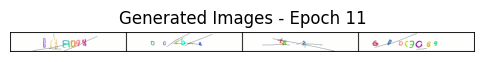

[11/200][0/157]	Loss_D: 0.1366	Loss_G: 5.0235	D(x): 0.9934	D(G(z)): 0.1101 / 0.0223
[11/200][50/157]	Loss_D: 0.0856	Loss_G: 4.4922	D(x): 0.9342	D(G(z)): 0.0130 / 0.0410
[11/200][100/157]	Loss_D: 0.0848	Loss_G: 5.3174	D(x): 0.9978	D(G(z)): 0.0630 / 0.0279
[11/200][150/157]	Loss_D: 0.2065	Loss_G: 3.8117	D(x): 0.9465	D(G(z)): 0.1125 / 0.0634


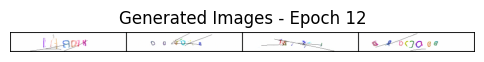

[12/200][0/157]	Loss_D: 0.3360	Loss_G: 3.5019	D(x): 0.9933	D(G(z)): 0.2244 / 0.0843
[12/200][50/157]	Loss_D: 0.1067	Loss_G: 4.8004	D(x): 0.9814	D(G(z)): 0.0778 / 0.0307
[12/200][100/157]	Loss_D: 0.0775	Loss_G: 4.4481	D(x): 0.9509	D(G(z)): 0.0227 / 0.0356
[12/200][150/157]	Loss_D: 0.0742	Loss_G: 3.9807	D(x): 0.9473	D(G(z)): 0.0165 / 0.0522


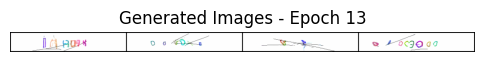

[13/200][0/157]	Loss_D: 0.0473	Loss_G: 5.1758	D(x): 0.9808	D(G(z)): 0.0261 / 0.0233
[13/200][50/157]	Loss_D: 0.0526	Loss_G: 4.0327	D(x): 0.9810	D(G(z)): 0.0316 / 0.0542
[13/200][100/157]	Loss_D: 0.2581	Loss_G: 6.0465	D(x): 0.9953	D(G(z)): 0.1683 / 0.0091
[13/200][150/157]	Loss_D: 0.0750	Loss_G: 3.5891	D(x): 0.9777	D(G(z)): 0.0484 / 0.0911


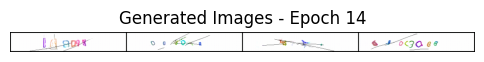

[14/200][0/157]	Loss_D: 0.2155	Loss_G: 4.7069	D(x): 0.9993	D(G(z)): 0.1596 / 0.0297
[14/200][50/157]	Loss_D: 0.0740	Loss_G: 2.8147	D(x): 0.9524	D(G(z)): 0.0214 / 0.1921
[14/200][100/157]	Loss_D: 0.0405	Loss_G: 6.0307	D(x): 0.9843	D(G(z)): 0.0233 / 0.0107
[14/200][150/157]	Loss_D: 0.1269	Loss_G: 3.2344	D(x): 0.9234	D(G(z)): 0.0391 / 0.1213


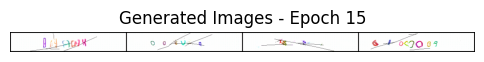

[15/200][0/157]	Loss_D: 4.6818	Loss_G: 11.7693	D(x): 1.0000	D(G(z)): 0.9297 / 0.0001
[15/200][50/157]	Loss_D: 0.3208	Loss_G: 3.4409	D(x): 0.8320	D(G(z)): 0.0411 / 0.1065
[15/200][100/157]	Loss_D: 0.1984	Loss_G: 5.9836	D(x): 0.8498	D(G(z)): 0.0073 / 0.0153
[15/200][150/157]	Loss_D: 0.1656	Loss_G: 5.4570	D(x): 0.9454	D(G(z)): 0.0727 / 0.0145


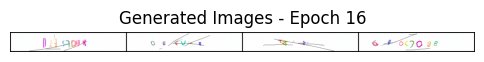

[16/200][0/157]	Loss_D: 0.1663	Loss_G: 4.5832	D(x): 0.9753	D(G(z)): 0.1070 / 0.0357
[16/200][50/157]	Loss_D: 0.0978	Loss_G: 5.8634	D(x): 0.9791	D(G(z)): 0.0634 / 0.0124
[16/200][100/157]	Loss_D: 0.0355	Loss_G: 5.0747	D(x): 0.9840	D(G(z)): 0.0184 / 0.0418
[16/200][150/157]	Loss_D: 0.0666	Loss_G: 5.9947	D(x): 0.9920	D(G(z)): 0.0517 / 0.0113


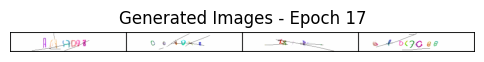

[17/200][0/157]	Loss_D: 1.3643	Loss_G: 12.1912	D(x): 0.9998	D(G(z)): 0.5957 / 0.0000
[17/200][50/157]	Loss_D: 1.4547	Loss_G: 1.3603	D(x): 0.3845	D(G(z)): 0.0031 / 0.4222
[17/200][100/157]	Loss_D: 0.1700	Loss_G: 4.4785	D(x): 0.9140	D(G(z)): 0.0573 / 0.0348
[17/200][150/157]	Loss_D: 0.1357	Loss_G: 2.6938	D(x): 0.9372	D(G(z)): 0.0584 / 0.1878


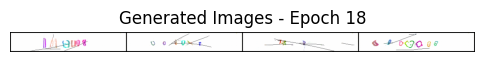

[18/200][0/157]	Loss_D: 0.8505	Loss_G: 8.9165	D(x): 0.9990	D(G(z)): 0.4573 / 0.0005
[18/200][50/157]	Loss_D: 0.1659	Loss_G: 4.3497	D(x): 0.9835	D(G(z)): 0.1248 / 0.0520
[18/200][100/157]	Loss_D: 0.1254	Loss_G: 4.5930	D(x): 0.9262	D(G(z)): 0.0362 / 0.0337
[18/200][150/157]	Loss_D: 0.1167	Loss_G: 4.1240	D(x): 0.9453	D(G(z)): 0.0475 / 0.0861


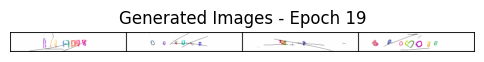

[19/200][0/157]	Loss_D: 0.2794	Loss_G: 6.1904	D(x): 0.9964	D(G(z)): 0.1947 / 0.0086
[19/200][50/157]	Loss_D: 0.0936	Loss_G: 6.8859	D(x): 0.9512	D(G(z)): 0.0310 / 0.0032
[19/200][100/157]	Loss_D: 0.0905	Loss_G: 4.9934	D(x): 0.9905	D(G(z)): 0.0582 / 0.0213
[19/200][150/157]	Loss_D: 1.0591	Loss_G: 10.0386	D(x): 0.9989	D(G(z)): 0.5155 / 0.0002


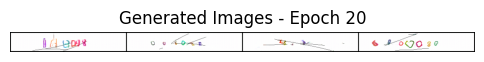

[20/200][0/157]	Loss_D: 3.3236	Loss_G: 0.3407	D(x): 0.1255	D(G(z)): 0.0199 / 0.7989
[20/200][50/157]	Loss_D: 0.2510	Loss_G: 4.1203	D(x): 0.8619	D(G(z)): 0.0624 / 0.0528
[20/200][100/157]	Loss_D: 0.7716	Loss_G: 4.6270	D(x): 0.9862	D(G(z)): 0.4052 / 0.0400
[20/200][150/157]	Loss_D: 0.0556	Loss_G: 3.7879	D(x): 0.9924	D(G(z)): 0.0427 / 0.0624


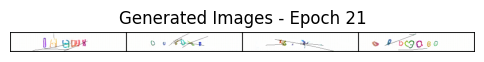

[21/200][0/157]	Loss_D: 0.0989	Loss_G: 4.7530	D(x): 0.9275	D(G(z)): 0.0168 / 0.0304
[21/200][50/157]	Loss_D: 0.1381	Loss_G: 4.7320	D(x): 0.9033	D(G(z)): 0.0269 / 0.0449
[21/200][100/157]	Loss_D: 0.1872	Loss_G: 4.5540	D(x): 0.8528	D(G(z)): 0.0077 / 0.0395
[21/200][150/157]	Loss_D: 0.6831	Loss_G: 1.0685	D(x): 0.6100	D(G(z)): 0.0013 / 0.4855


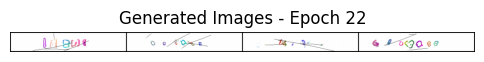

[22/200][0/157]	Loss_D: 2.7500	Loss_G: 7.7094	D(x): 0.9995	D(G(z)): 0.7918 / 0.0023
[22/200][50/157]	Loss_D: 0.1647	Loss_G: 4.5477	D(x): 0.9106	D(G(z)): 0.0429 / 0.0515
[22/200][100/157]	Loss_D: 0.2410	Loss_G: 6.4487	D(x): 0.9482	D(G(z)): 0.1389 / 0.0088
[22/200][150/157]	Loss_D: 0.0265	Loss_G: 4.4458	D(x): 0.9849	D(G(z)): 0.0107 / 0.0442


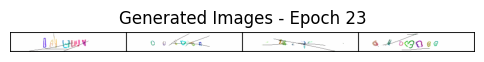

[23/200][0/157]	Loss_D: 0.6108	Loss_G: 8.2664	D(x): 0.9993	D(G(z)): 0.3552 / 0.0010
[23/200][50/157]	Loss_D: 0.1332	Loss_G: 4.1151	D(x): 0.9086	D(G(z)): 0.0224 / 0.0546
[23/200][100/157]	Loss_D: 0.0996	Loss_G: 5.2716	D(x): 0.9910	D(G(z)): 0.0774 / 0.0244
[23/200][150/157]	Loss_D: 0.0572	Loss_G: 5.7063	D(x): 0.9702	D(G(z)): 0.0205 / 0.0145


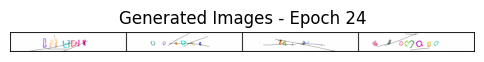

[24/200][0/157]	Loss_D: 0.0853	Loss_G: 5.2821	D(x): 0.9400	D(G(z)): 0.0200 / 0.0309
[24/200][50/157]	Loss_D: 0.0873	Loss_G: 3.3761	D(x): 0.9435	D(G(z)): 0.0226 / 0.1256
[24/200][100/157]	Loss_D: 0.0639	Loss_G: 4.2154	D(x): 0.9851	D(G(z)): 0.0447 / 0.0496
[24/200][150/157]	Loss_D: 0.0877	Loss_G: 4.5240	D(x): 0.9894	D(G(z)): 0.0677 / 0.0426


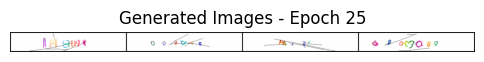

[25/200][0/157]	Loss_D: 0.2106	Loss_G: 5.3208	D(x): 0.9898	D(G(z)): 0.1561 / 0.0276
[25/200][50/157]	Loss_D: 0.0514	Loss_G: 3.9087	D(x): 0.9808	D(G(z)): 0.0300 / 0.0607
[25/200][100/157]	Loss_D: 1.1208	Loss_G: 0.9117	D(x): 0.4554	D(G(z)): 0.0252 / 0.6042
[25/200][150/157]	Loss_D: 0.3711	Loss_G: 6.0483	D(x): 0.9904	D(G(z)): 0.2212 / 0.0091


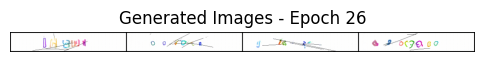

[26/200][0/157]	Loss_D: 0.6446	Loss_G: 6.5390	D(x): 0.9891	D(G(z)): 0.3585 / 0.0042
[26/200][50/157]	Loss_D: 0.0790	Loss_G: 4.5935	D(x): 0.9477	D(G(z)): 0.0185 / 0.0335
[26/200][100/157]	Loss_D: 0.1153	Loss_G: 4.1138	D(x): 0.9255	D(G(z)): 0.0257 / 0.0493
[26/200][150/157]	Loss_D: 0.7401	Loss_G: 2.2381	D(x): 0.9382	D(G(z)): 0.3732 / 0.2049


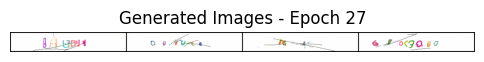

[27/200][0/157]	Loss_D: 0.1936	Loss_G: 3.4014	D(x): 0.9303	D(G(z)): 0.0787 / 0.0827
[27/200][50/157]	Loss_D: 0.1602	Loss_G: 2.9111	D(x): 0.8952	D(G(z)): 0.0292 / 0.1191
[27/200][100/157]	Loss_D: 0.0888	Loss_G: 4.1642	D(x): 0.9963	D(G(z)): 0.0716 / 0.0488
[27/200][150/157]	Loss_D: 0.0561	Loss_G: 4.4269	D(x): 0.9841	D(G(z)): 0.0357 / 0.0551


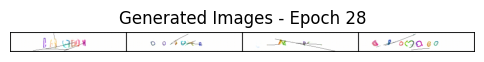

[28/200][0/157]	Loss_D: 0.0900	Loss_G: 3.3945	D(x): 0.9328	D(G(z)): 0.0139 / 0.1021
[28/200][50/157]	Loss_D: 0.5717	Loss_G: 5.6159	D(x): 0.8717	D(G(z)): 0.2415 / 0.0166
[28/200][100/157]	Loss_D: 0.2181	Loss_G: 4.3861	D(x): 0.9566	D(G(z)): 0.1376 / 0.0601
[28/200][150/157]	Loss_D: 0.1696	Loss_G: 3.7270	D(x): 0.8767	D(G(z)): 0.0113 / 0.0848


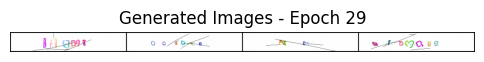

[29/200][0/157]	Loss_D: 0.1740	Loss_G: 2.6187	D(x): 0.8627	D(G(z)): 0.0081 / 0.1888
[29/200][50/157]	Loss_D: 0.0919	Loss_G: 3.6375	D(x): 0.9621	D(G(z)): 0.0451 / 0.0611
[29/200][100/157]	Loss_D: 0.3014	Loss_G: 4.1903	D(x): 0.7907	D(G(z)): 0.0040 / 0.0574
[29/200][150/157]	Loss_D: 0.1289	Loss_G: 3.7916	D(x): 0.9080	D(G(z)): 0.0153 / 0.0765


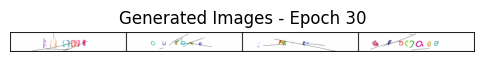

[30/200][0/157]	Loss_D: 0.1456	Loss_G: 4.8917	D(x): 0.9664	D(G(z)): 0.0805 / 0.0330
[30/200][50/157]	Loss_D: 0.0465	Loss_G: 5.5105	D(x): 0.9925	D(G(z)): 0.0367 / 0.0131
[30/200][100/157]	Loss_D: 0.2260	Loss_G: 1.1201	D(x): 0.9572	D(G(z)): 0.1362 / 0.4699
[30/200][150/157]	Loss_D: 0.1759	Loss_G: 2.9262	D(x): 0.8807	D(G(z)): 0.0227 / 0.1147


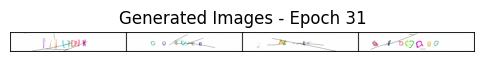

[31/200][0/157]	Loss_D: 0.5008	Loss_G: 2.4052	D(x): 0.7047	D(G(z)): 0.0137 / 0.2257
[31/200][50/157]	Loss_D: 0.1801	Loss_G: 4.3451	D(x): 0.8740	D(G(z)): 0.0222 / 0.0567
[31/200][100/157]	Loss_D: 0.3870	Loss_G: 1.5583	D(x): 0.7455	D(G(z)): 0.0206 / 0.3818
[31/200][150/157]	Loss_D: 0.3446	Loss_G: 3.0025	D(x): 0.8524	D(G(z)): 0.1170 / 0.1261


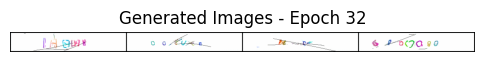

[32/200][0/157]	Loss_D: 1.9464	Loss_G: 8.8511	D(x): 0.9969	D(G(z)): 0.7098 / 0.0011
[32/200][50/157]	Loss_D: 0.2120	Loss_G: 4.1461	D(x): 0.8468	D(G(z)): 0.0130 / 0.0611
[32/200][100/157]	Loss_D: 0.0653	Loss_G: 3.6692	D(x): 0.9656	D(G(z)): 0.0278 / 0.0787
[32/200][150/157]	Loss_D: 0.1315	Loss_G: 4.6758	D(x): 0.9117	D(G(z)): 0.0232 / 0.0500


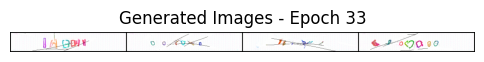

[33/200][0/157]	Loss_D: 3.9096	Loss_G: 10.4329	D(x): 0.9999	D(G(z)): 0.9132 / 0.0002
[33/200][50/157]	Loss_D: 0.1287	Loss_G: 4.1628	D(x): 0.9695	D(G(z)): 0.0841 / 0.0620
[33/200][100/157]	Loss_D: 0.2308	Loss_G: 4.4715	D(x): 0.9889	D(G(z)): 0.1732 / 0.0406
[33/200][150/157]	Loss_D: 0.0885	Loss_G: 3.5758	D(x): 0.9425	D(G(z)): 0.0234 / 0.0899


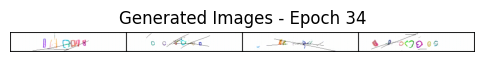

[34/200][0/157]	Loss_D: 0.0633	Loss_G: 4.9761	D(x): 0.9534	D(G(z)): 0.0118 / 0.0283
[34/200][50/157]	Loss_D: 0.0462	Loss_G: 3.7640	D(x): 0.9862	D(G(z)): 0.0294 / 0.0747
[34/200][100/157]	Loss_D: 0.1233	Loss_G: 4.7964	D(x): 0.9317	D(G(z)): 0.0290 / 0.0460
[34/200][150/157]	Loss_D: 0.0511	Loss_G: 5.1978	D(x): 0.9743	D(G(z)): 0.0227 / 0.0218


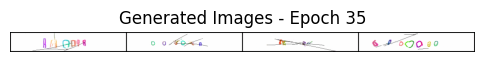

[35/200][0/157]	Loss_D: 0.2699	Loss_G: 6.1808	D(x): 0.9985	D(G(z)): 0.1615 / 0.0062
[35/200][50/157]	Loss_D: 0.0682	Loss_G: 5.8975	D(x): 0.9484	D(G(z)): 0.0125 / 0.0101
[35/200][100/157]	Loss_D: 0.1452	Loss_G: 3.1553	D(x): 0.9422	D(G(z)): 0.0542 / 0.1172
[35/200][150/157]	Loss_D: 0.0993	Loss_G: 5.0330	D(x): 0.9930	D(G(z)): 0.0782 / 0.0207


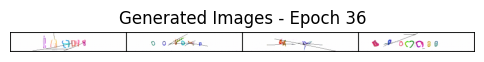

[36/200][0/157]	Loss_D: 0.3453	Loss_G: 4.6928	D(x): 0.7568	D(G(z)): 0.0042 / 0.0424
[36/200][50/157]	Loss_D: 0.1224	Loss_G: 5.5094	D(x): 0.9704	D(G(z)): 0.0810 / 0.0257
[36/200][100/157]	Loss_D: 0.4183	Loss_G: 2.0498	D(x): 0.8114	D(G(z)): 0.1334 / 0.2380
[36/200][150/157]	Loss_D: 0.1193	Loss_G: 3.5401	D(x): 0.9177	D(G(z)): 0.0141 / 0.0878


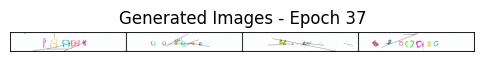

[37/200][0/157]	Loss_D: 0.1496	Loss_G: 5.0206	D(x): 0.9620	D(G(z)): 0.0631 / 0.0308
[37/200][50/157]	Loss_D: 0.1640	Loss_G: 3.1804	D(x): 0.9257	D(G(z)): 0.0658 / 0.1053
[37/200][100/157]	Loss_D: 0.1045	Loss_G: 5.7169	D(x): 0.9843	D(G(z)): 0.0725 / 0.0087
[37/200][150/157]	Loss_D: 0.0573	Loss_G: 4.8725	D(x): 0.9892	D(G(z)): 0.0268 / 0.0315


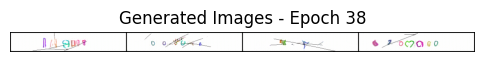

[38/200][0/157]	Loss_D: 0.3444	Loss_G: 2.8186	D(x): 0.7664	D(G(z)): 0.0229 / 0.2041
[38/200][50/157]	Loss_D: 0.0404	Loss_G: 5.2452	D(x): 0.9924	D(G(z)): 0.0304 / 0.0196
[38/200][100/157]	Loss_D: 0.0999	Loss_G: 6.0077	D(x): 0.9909	D(G(z)): 0.0648 / 0.0123
[38/200][150/157]	Loss_D: 0.1332	Loss_G: 6.7828	D(x): 0.9939	D(G(z)): 0.1007 / 0.0056


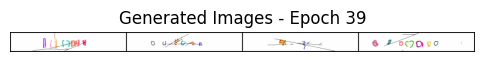

[39/200][0/157]	Loss_D: 0.0535	Loss_G: 6.0306	D(x): 0.9647	D(G(z)): 0.0148 / 0.0091
[39/200][50/157]	Loss_D: 1.0259	Loss_G: 8.2347	D(x): 0.9999	D(G(z)): 0.5195 / 0.0009
[39/200][100/157]	Loss_D: 0.1614	Loss_G: 3.8628	D(x): 0.9486	D(G(z)): 0.0838 / 0.0693
[39/200][150/157]	Loss_D: 0.1219	Loss_G: 4.7651	D(x): 0.9147	D(G(z)): 0.0189 / 0.0321


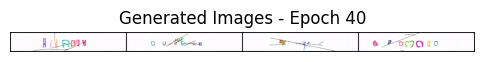

[40/200][0/157]	Loss_D: 0.2863	Loss_G: 2.6930	D(x): 0.8000	D(G(z)): 0.0029 / 0.1813
[40/200][50/157]	Loss_D: 0.2364	Loss_G: 3.0239	D(x): 0.8477	D(G(z)): 0.0451 / 0.1517
[40/200][100/157]	Loss_D: 0.0921	Loss_G: 5.6330	D(x): 0.9363	D(G(z)): 0.0199 / 0.0191
[40/200][150/157]	Loss_D: 0.5694	Loss_G: 2.8594	D(x): 0.6755	D(G(z)): 0.0026 / 0.2420


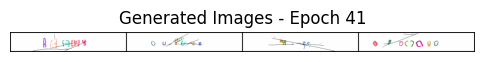

[41/200][0/157]	Loss_D: 0.6040	Loss_G: 1.0874	D(x): 0.6315	D(G(z)): 0.0038 / 0.5324
[41/200][50/157]	Loss_D: 0.3117	Loss_G: 4.6815	D(x): 0.9749	D(G(z)): 0.2089 / 0.0317
[41/200][100/157]	Loss_D: 0.1089	Loss_G: 5.2248	D(x): 0.9275	D(G(z)): 0.0126 / 0.0313
[41/200][150/157]	Loss_D: 0.1983	Loss_G: 5.0461	D(x): 0.9808	D(G(z)): 0.1408 / 0.0396


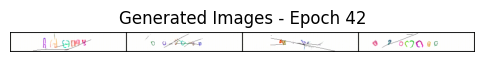

[42/200][0/157]	Loss_D: 0.1136	Loss_G: 4.4233	D(x): 0.9762	D(G(z)): 0.0734 / 0.0489
[42/200][50/157]	Loss_D: 0.0382	Loss_G: 4.3958	D(x): 0.9868	D(G(z)): 0.0232 / 0.0459
[42/200][100/157]	Loss_D: 0.0845	Loss_G: 4.9806	D(x): 0.9776	D(G(z)): 0.0528 / 0.0286
[42/200][150/157]	Loss_D: 1.2350	Loss_G: 2.5047	D(x): 0.4553	D(G(z)): 0.0011 / 0.2670


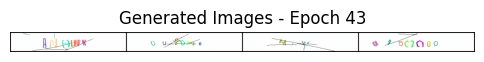

[43/200][0/157]	Loss_D: 1.4283	Loss_G: 8.2213	D(x): 0.9985	D(G(z)): 0.6332 / 0.0012
[43/200][50/157]	Loss_D: 0.1087	Loss_G: 5.4250	D(x): 0.9682	D(G(z)): 0.0672 / 0.0191
[43/200][100/157]	Loss_D: 0.3404	Loss_G: 2.5358	D(x): 0.7937	D(G(z)): 0.0227 / 0.2126
[43/200][150/157]	Loss_D: 0.0862	Loss_G: 5.1411	D(x): 0.9829	D(G(z)): 0.0521 / 0.0196


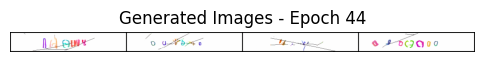

[44/200][0/157]	Loss_D: 0.3557	Loss_G: 7.5127	D(x): 0.9969	D(G(z)): 0.2558 / 0.0034
[44/200][50/157]	Loss_D: 0.0978	Loss_G: 3.6710	D(x): 0.9342	D(G(z)): 0.0210 / 0.0807
[44/200][100/157]	Loss_D: 0.1016	Loss_G: 6.6907	D(x): 0.9127	D(G(z)): 0.0038 / 0.0056
[44/200][150/157]	Loss_D: 0.0753	Loss_G: 4.2046	D(x): 0.9514	D(G(z)): 0.0185 / 0.0489


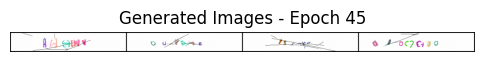

[45/200][0/157]	Loss_D: 0.2659	Loss_G: 5.7394	D(x): 0.9987	D(G(z)): 0.1930 / 0.0085
[45/200][50/157]	Loss_D: 0.0461	Loss_G: 5.7876	D(x): 0.9645	D(G(z)): 0.0091 / 0.0237
[45/200][100/157]	Loss_D: 1.1225	Loss_G: 9.3376	D(x): 0.9996	D(G(z)): 0.5128 / 0.0007
[45/200][150/157]	Loss_D: 0.1954	Loss_G: 3.8105	D(x): 0.8847	D(G(z)): 0.0347 / 0.0754


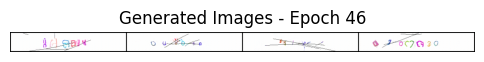

[46/200][0/157]	Loss_D: 1.1093	Loss_G: 0.6302	D(x): 0.5776	D(G(z)): 0.1148 / 0.6802
[46/200][50/157]	Loss_D: 0.0692	Loss_G: 4.2023	D(x): 0.9860	D(G(z)): 0.0503 / 0.0519
[46/200][100/157]	Loss_D: 0.1006	Loss_G: 4.7767	D(x): 0.9913	D(G(z)): 0.0684 / 0.0369
[46/200][150/157]	Loss_D: 0.0827	Loss_G: 4.6717	D(x): 0.9725	D(G(z)): 0.0495 / 0.0459


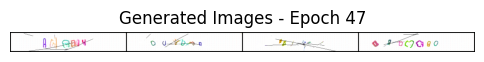

[47/200][0/157]	Loss_D: 0.0428	Loss_G: 3.2660	D(x): 0.9886	D(G(z)): 0.0294 / 0.1177
[47/200][50/157]	Loss_D: 0.0880	Loss_G: 4.5434	D(x): 0.9294	D(G(z)): 0.0093 / 0.0449
[47/200][100/157]	Loss_D: 0.1776	Loss_G: 5.1435	D(x): 0.9861	D(G(z)): 0.1316 / 0.0195
[47/200][150/157]	Loss_D: 0.2277	Loss_G: 3.0958	D(x): 0.9909	D(G(z)): 0.1463 / 0.1265


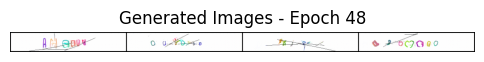

[48/200][0/157]	Loss_D: 0.2128	Loss_G: 5.7263	D(x): 0.9495	D(G(z)): 0.1274 / 0.0115
[48/200][50/157]	Loss_D: 0.1757	Loss_G: 6.0137	D(x): 0.9886	D(G(z)): 0.1297 / 0.0094
[48/200][100/157]	Loss_D: 0.3569	Loss_G: 6.0437	D(x): 0.9459	D(G(z)): 0.1701 / 0.0091
[48/200][150/157]	Loss_D: 0.1526	Loss_G: 3.8029	D(x): 0.9081	D(G(z)): 0.0389 / 0.0724


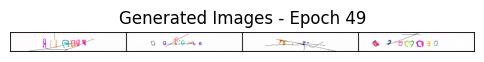

[49/200][0/157]	Loss_D: 0.0991	Loss_G: 5.0034	D(x): 0.9432	D(G(z)): 0.0317 / 0.0281
[49/200][50/157]	Loss_D: 0.0865	Loss_G: 5.8352	D(x): 0.9277	D(G(z)): 0.0052 / 0.0097
[49/200][100/157]	Loss_D: 0.1973	Loss_G: 5.4225	D(x): 0.9966	D(G(z)): 0.1573 / 0.0362
[49/200][150/157]	Loss_D: 0.0609	Loss_G: 5.4001	D(x): 0.9664	D(G(z)): 0.0229 / 0.0159


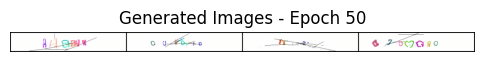

[50/200][0/157]	Loss_D: 0.0216	Loss_G: 5.3377	D(x): 0.9878	D(G(z)): 0.0090 / 0.0250
[50/200][50/157]	Loss_D: 0.1449	Loss_G: 3.9087	D(x): 0.9099	D(G(z)): 0.0346 / 0.0714
[50/200][100/157]	Loss_D: 0.2655	Loss_G: 6.2144	D(x): 0.9886	D(G(z)): 0.1786 / 0.0081
[50/200][150/157]	Loss_D: 0.0483	Loss_G: 6.9144	D(x): 0.9850	D(G(z)): 0.0303 / 0.0038


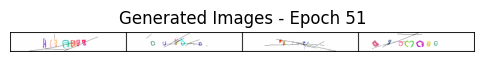

[51/200][0/157]	Loss_D: 0.2800	Loss_G: 7.1965	D(x): 0.9822	D(G(z)): 0.1830 / 0.0040
[51/200][50/157]	Loss_D: 0.0722	Loss_G: 5.0981	D(x): 0.9726	D(G(z)): 0.0387 / 0.0327
[51/200][100/157]	Loss_D: 0.6589	Loss_G: 4.2231	D(x): 0.9906	D(G(z)): 0.3898 / 0.0394
[51/200][150/157]	Loss_D: 0.7155	Loss_G: 3.2696	D(x): 0.6194	D(G(z)): 0.0029 / 0.1136


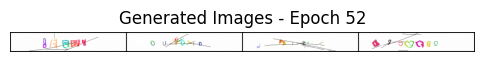

[52/200][0/157]	Loss_D: 0.9394	Loss_G: 2.2837	D(x): 0.6218	D(G(z)): 0.0022 / 0.2308
[52/200][50/157]	Loss_D: 0.1574	Loss_G: 2.2778	D(x): 0.8732	D(G(z)): 0.0087 / 0.2160
[52/200][100/157]	Loss_D: 0.1860	Loss_G: 3.7285	D(x): 0.9075	D(G(z)): 0.0585 / 0.0815
[52/200][150/157]	Loss_D: 0.1330	Loss_G: 4.1844	D(x): 0.9552	D(G(z)): 0.0675 / 0.0387


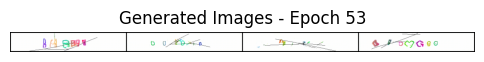

[53/200][0/157]	Loss_D: 0.2143	Loss_G: 4.3600	D(x): 0.8833	D(G(z)): 0.0674 / 0.0328
[53/200][50/157]	Loss_D: 0.0880	Loss_G: 4.3857	D(x): 0.9752	D(G(z)): 0.0495 / 0.0658
[53/200][100/157]	Loss_D: 0.4161	Loss_G: 4.9233	D(x): 0.9929	D(G(z)): 0.2373 / 0.0320
[53/200][150/157]	Loss_D: 0.0491	Loss_G: 6.0194	D(x): 0.9858	D(G(z)): 0.0322 / 0.0093


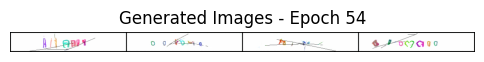

[54/200][0/157]	Loss_D: 0.0471	Loss_G: 5.5245	D(x): 0.9842	D(G(z)): 0.0278 / 0.0260
[54/200][50/157]	Loss_D: 0.0434	Loss_G: 4.8207	D(x): 0.9804	D(G(z)): 0.0221 / 0.0327
[54/200][100/157]	Loss_D: 0.2336	Loss_G: 6.5939	D(x): 0.9856	D(G(z)): 0.1667 / 0.0049
[54/200][150/157]	Loss_D: 0.1600	Loss_G: 3.3556	D(x): 0.8813	D(G(z)): 0.0032 / 0.0837


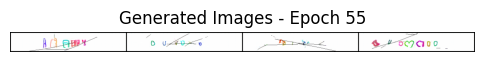

[55/200][0/157]	Loss_D: 0.5970	Loss_G: 8.0790	D(x): 0.9965	D(G(z)): 0.2764 / 0.0018
[55/200][50/157]	Loss_D: 0.3724	Loss_G: 4.5939	D(x): 0.7667	D(G(z)): 0.0183 / 0.0380
[55/200][100/157]	Loss_D: 0.2535	Loss_G: 4.3633	D(x): 0.8579	D(G(z)): 0.0416 / 0.0489
[55/200][150/157]	Loss_D: 0.0642	Loss_G: 5.2691	D(x): 0.9594	D(G(z)): 0.0187 / 0.0229


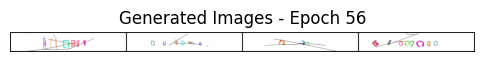

[56/200][0/157]	Loss_D: 0.1606	Loss_G: 4.7430	D(x): 0.9931	D(G(z)): 0.1308 / 0.0466
[56/200][50/157]	Loss_D: 0.1414	Loss_G: 6.2207	D(x): 0.9706	D(G(z)): 0.0838 / 0.0107
[56/200][100/157]	Loss_D: 0.1346	Loss_G: 4.3788	D(x): 0.9228	D(G(z)): 0.0387 / 0.0539
[56/200][150/157]	Loss_D: 0.0702	Loss_G: 4.7766	D(x): 0.9632	D(G(z)): 0.0274 / 0.0395


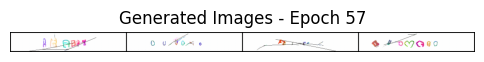

[57/200][0/157]	Loss_D: 0.0949	Loss_G: 6.1528	D(x): 0.9838	D(G(z)): 0.0688 / 0.0079
[57/200][50/157]	Loss_D: 1.6338	Loss_G: 2.6855	D(x): 0.9852	D(G(z)): 0.6502 / 0.1406
[57/200][100/157]	Loss_D: 0.2311	Loss_G: 4.2053	D(x): 0.9272	D(G(z)): 0.1228 / 0.0504
[57/200][150/157]	Loss_D: 0.1234	Loss_G: 4.4703	D(x): 0.9584	D(G(z)): 0.0561 / 0.0537


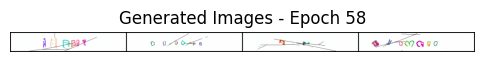

[58/200][0/157]	Loss_D: 0.1203	Loss_G: 3.8291	D(x): 0.9234	D(G(z)): 0.0285 / 0.0883
[58/200][50/157]	Loss_D: 0.1748	Loss_G: 6.1004	D(x): 0.9880	D(G(z)): 0.1249 / 0.0200
[58/200][100/157]	Loss_D: 0.1853	Loss_G: 5.5791	D(x): 0.9957	D(G(z)): 0.1461 / 0.0148
[58/200][150/157]	Loss_D: 0.0342	Loss_G: 7.1043	D(x): 0.9897	D(G(z)): 0.0224 / 0.0047


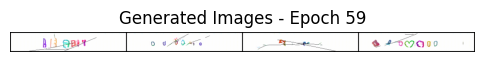

[59/200][0/157]	Loss_D: 0.0742	Loss_G: 3.9890	D(x): 0.9584	D(G(z)): 0.0179 / 0.0671
[59/200][50/157]	Loss_D: 0.8075	Loss_G: 3.0470	D(x): 0.9048	D(G(z)): 0.4136 / 0.1080
[59/200][100/157]	Loss_D: 0.1944	Loss_G: 3.4125	D(x): 0.9120	D(G(z)): 0.0687 / 0.0944
[59/200][150/157]	Loss_D: 0.1303	Loss_G: 4.7555	D(x): 0.9312	D(G(z)): 0.0432 / 0.0378


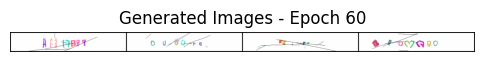

[60/200][0/157]	Loss_D: 0.3170	Loss_G: 5.3116	D(x): 0.9983	D(G(z)): 0.2232 / 0.0215
[60/200][50/157]	Loss_D: 0.0477	Loss_G: 4.4694	D(x): 0.9660	D(G(z)): 0.0115 / 0.0446
[60/200][100/157]	Loss_D: 0.0380	Loss_G: 3.5589	D(x): 0.9867	D(G(z)): 0.0235 / 0.0974
[60/200][150/157]	Loss_D: 0.3547	Loss_G: 6.0193	D(x): 0.9730	D(G(z)): 0.2318 / 0.0080


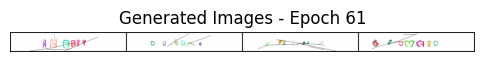

[61/200][0/157]	Loss_D: 0.6100	Loss_G: 1.4143	D(x): 0.7208	D(G(z)): 0.0811 / 0.4624
[61/200][50/157]	Loss_D: 0.0471	Loss_G: 4.5263	D(x): 0.9869	D(G(z)): 0.0311 / 0.0480
[61/200][100/157]	Loss_D: 0.1102	Loss_G: 5.7922	D(x): 0.9138	D(G(z)): 0.0110 / 0.0181
[61/200][150/157]	Loss_D: 0.5998	Loss_G: 4.8322	D(x): 0.6319	D(G(z)): 0.0134 / 0.0503


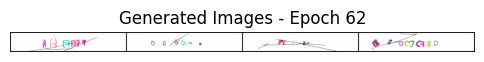

[62/200][0/157]	Loss_D: 0.8560	Loss_G: 4.2620	D(x): 0.5376	D(G(z)): 0.0046 / 0.0816
[62/200][50/157]	Loss_D: 0.0946	Loss_G: 5.7978	D(x): 0.9898	D(G(z)): 0.0682 / 0.0160
[62/200][100/157]	Loss_D: 0.1164	Loss_G: 4.1410	D(x): 0.9427	D(G(z)): 0.0407 / 0.0617
[62/200][150/157]	Loss_D: 0.1471	Loss_G: 5.2761	D(x): 0.9800	D(G(z)): 0.0961 / 0.0315


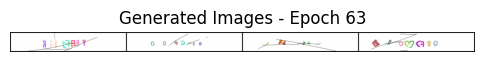

[63/200][0/157]	Loss_D: 0.7147	Loss_G: 7.3648	D(x): 0.9996	D(G(z)): 0.4232 / 0.0050
[63/200][50/157]	Loss_D: 0.0584	Loss_G: 5.9807	D(x): 0.9888	D(G(z)): 0.0434 / 0.0108
[63/200][100/157]	Loss_D: 0.0914	Loss_G: 4.4799	D(x): 0.9469	D(G(z)): 0.0251 / 0.0425
[63/200][150/157]	Loss_D: 0.2053	Loss_G: 4.2111	D(x): 0.8921	D(G(z)): 0.0559 / 0.0573


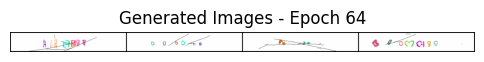

[64/200][0/157]	Loss_D: 1.5954	Loss_G: 10.5059	D(x): 0.9994	D(G(z)): 0.6315 / 0.0002
[64/200][50/157]	Loss_D: 0.1115	Loss_G: 5.9406	D(x): 0.9720	D(G(z)): 0.0726 / 0.0141
[64/200][100/157]	Loss_D: 0.0343	Loss_G: 6.4284	D(x): 0.9934	D(G(z)): 0.0263 / 0.0060
[64/200][150/157]	Loss_D: 0.3381	Loss_G: 3.1250	D(x): 0.7677	D(G(z)): 0.0043 / 0.1453


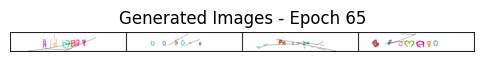

[65/200][0/157]	Loss_D: 0.0948	Loss_G: 5.2592	D(x): 0.9968	D(G(z)): 0.0811 / 0.0270
[65/200][50/157]	Loss_D: 0.4552	Loss_G: 0.8188	D(x): 0.6987	D(G(z)): 0.0132 / 0.6436
[65/200][100/157]	Loss_D: 0.0788	Loss_G: 4.4785	D(x): 0.9699	D(G(z)): 0.0419 / 0.0354
[65/200][150/157]	Loss_D: 0.1161	Loss_G: 5.1353	D(x): 0.9292	D(G(z)): 0.0181 / 0.0147


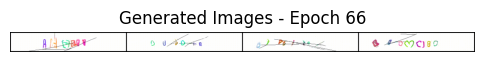

[66/200][0/157]	Loss_D: 0.1571	Loss_G: 5.7341	D(x): 0.8830	D(G(z)): 0.0036 / 0.0241
[66/200][50/157]	Loss_D: 0.1099	Loss_G: 4.3107	D(x): 0.9268	D(G(z)): 0.0197 / 0.0393
[66/200][100/157]	Loss_D: 0.1813	Loss_G: 3.5070	D(x): 0.8728	D(G(z)): 0.0219 / 0.1213
[66/200][150/157]	Loss_D: 0.6104	Loss_G: 6.7421	D(x): 0.9995	D(G(z)): 0.3550 / 0.0065


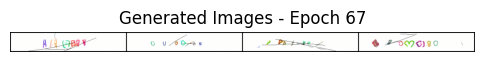

[67/200][0/157]	Loss_D: 0.0614	Loss_G: 7.4342	D(x): 0.9506	D(G(z)): 0.0063 / 0.0038
[67/200][50/157]	Loss_D: 0.2947	Loss_G: 2.0414	D(x): 0.9772	D(G(z)): 0.2075 / 0.2513
[67/200][100/157]	Loss_D: 0.1317	Loss_G: 5.0506	D(x): 0.9408	D(G(z)): 0.0490 / 0.0348
[67/200][150/157]	Loss_D: 0.1897	Loss_G: 3.7914	D(x): 0.8575	D(G(z)): 0.0123 / 0.0735


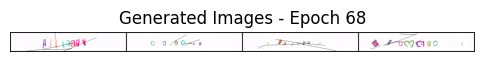

[68/200][0/157]	Loss_D: 0.0527	Loss_G: 5.0363	D(x): 0.9695	D(G(z)): 0.0190 / 0.0202
[68/200][50/157]	Loss_D: 0.2340	Loss_G: 3.4397	D(x): 0.8275	D(G(z)): 0.0019 / 0.0780
[68/200][100/157]	Loss_D: 0.1319	Loss_G: 4.6295	D(x): 0.8971	D(G(z)): 0.0073 / 0.0408
[68/200][150/157]	Loss_D: 0.3683	Loss_G: 1.3355	D(x): 0.7563	D(G(z)): 0.0198 / 0.4341


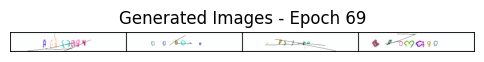

[69/200][0/157]	Loss_D: 0.5280	Loss_G: 4.4874	D(x): 0.9894	D(G(z)): 0.3311 / 0.0318
[69/200][50/157]	Loss_D: 0.0987	Loss_G: 5.6431	D(x): 0.9657	D(G(z)): 0.0558 / 0.0117
[69/200][100/157]	Loss_D: 0.0853	Loss_G: 5.3464	D(x): 0.9459	D(G(z)): 0.0194 / 0.0312
[69/200][150/157]	Loss_D: 0.1763	Loss_G: 7.1415	D(x): 0.9759	D(G(z)): 0.1041 / 0.0035


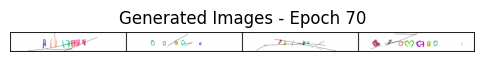

[70/200][0/157]	Loss_D: 0.8482	Loss_G: 7.0252	D(x): 0.9899	D(G(z)): 0.4480 / 0.0050
[70/200][50/157]	Loss_D: 0.5503	Loss_G: 3.6998	D(x): 0.6691	D(G(z)): 0.0080 / 0.0801
[70/200][100/157]	Loss_D: 0.1025	Loss_G: 4.2550	D(x): 0.9554	D(G(z)): 0.0463 / 0.0453
[70/200][150/157]	Loss_D: 0.0489	Loss_G: 5.3187	D(x): 0.9730	D(G(z)): 0.0199 / 0.0247


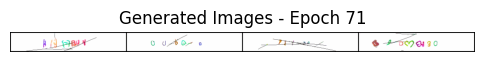

[71/200][0/157]	Loss_D: 1.1557	Loss_G: 8.5630	D(x): 0.9997	D(G(z)): 0.5535 / 0.0008
[71/200][50/157]	Loss_D: 0.1139	Loss_G: 5.6350	D(x): 0.9927	D(G(z)): 0.0902 / 0.0148
[71/200][100/157]	Loss_D: 0.0551	Loss_G: 5.5970	D(x): 0.9612	D(G(z)): 0.0130 / 0.0151
[71/200][150/157]	Loss_D: 0.2007	Loss_G: 1.9201	D(x): 0.8479	D(G(z)): 0.0092 / 0.2736


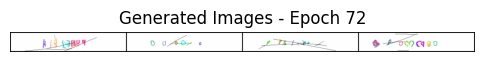

[72/200][0/157]	Loss_D: 1.6967	Loss_G: 3.6032	D(x): 0.9876	D(G(z)): 0.6367 / 0.0896
[72/200][50/157]	Loss_D: 0.0438	Loss_G: 5.0871	D(x): 0.9935	D(G(z)): 0.0353 / 0.0314
[72/200][100/157]	Loss_D: 0.1640	Loss_G: 4.2856	D(x): 0.8796	D(G(z)): 0.0113 / 0.0475
[72/200][150/157]	Loss_D: 0.1237	Loss_G: 4.6949	D(x): 0.9030	D(G(z)): 0.0071 / 0.0373


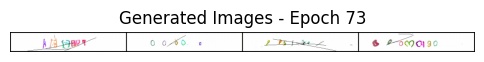

[73/200][0/157]	Loss_D: 1.1790	Loss_G: 11.4149	D(x): 0.9997	D(G(z)): 0.5723 / 0.0001
[73/200][50/157]	Loss_D: 0.2663	Loss_G: 3.7219	D(x): 0.8255	D(G(z)): 0.0158 / 0.0989
[73/200][100/157]	Loss_D: 0.0844	Loss_G: 5.0493	D(x): 0.9745	D(G(z)): 0.0516 / 0.0265
[73/200][150/157]	Loss_D: 0.0421	Loss_G: 5.5299	D(x): 0.9805	D(G(z)): 0.0210 / 0.0112


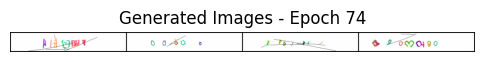

[74/200][0/157]	Loss_D: 0.0798	Loss_G: 4.5907	D(x): 0.9450	D(G(z)): 0.0195 / 0.0365
[74/200][50/157]	Loss_D: 0.1048	Loss_G: 6.1548	D(x): 0.9956	D(G(z)): 0.0829 / 0.0191
[74/200][100/157]	Loss_D: 0.1367	Loss_G: 6.6768	D(x): 0.9988	D(G(z)): 0.1072 / 0.0043
[74/200][150/157]	Loss_D: 0.0992	Loss_G: 5.2696	D(x): 0.9929	D(G(z)): 0.0606 / 0.0374


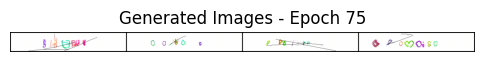

[75/200][0/157]	Loss_D: 0.0426	Loss_G: 5.3438	D(x): 0.9850	D(G(z)): 0.0259 / 0.0333
[75/200][50/157]	Loss_D: 0.0384	Loss_G: 3.7135	D(x): 0.9712	D(G(z)): 0.0077 / 0.0919
[75/200][100/157]	Loss_D: 0.0375	Loss_G: 4.7746	D(x): 0.9763	D(G(z)): 0.0120 / 0.0302
[75/200][150/157]	Loss_D: 0.8188	Loss_G: 0.8392	D(x): 0.5770	D(G(z)): 0.0860 / 0.7086


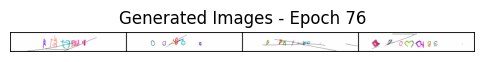

[76/200][0/157]	Loss_D: 0.1605	Loss_G: 6.6009	D(x): 0.9599	D(G(z)): 0.1014 / 0.0043
[76/200][50/157]	Loss_D: 0.0492	Loss_G: 3.1496	D(x): 0.9799	D(G(z)): 0.0269 / 0.1553
[76/200][100/157]	Loss_D: 0.1757	Loss_G: 4.7334	D(x): 0.8825	D(G(z)): 0.0152 / 0.0278
[76/200][150/157]	Loss_D: 0.3050	Loss_G: 4.2472	D(x): 0.8084	D(G(z)): 0.0224 / 0.0515


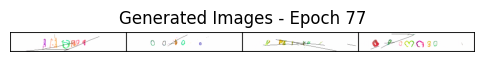

[77/200][0/157]	Loss_D: 0.1767	Loss_G: 4.1217	D(x): 0.8710	D(G(z)): 0.0095 / 0.0671
[77/200][50/157]	Loss_D: 0.1500	Loss_G: 4.4459	D(x): 0.8923	D(G(z)): 0.0201 / 0.0366
[77/200][100/157]	Loss_D: 0.1403	Loss_G: 5.2880	D(x): 0.9883	D(G(z)): 0.1015 / 0.0321
[77/200][150/157]	Loss_D: 0.2520	Loss_G: 5.0775	D(x): 0.9990	D(G(z)): 0.1871 / 0.0407


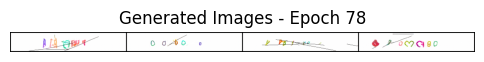

[78/200][0/157]	Loss_D: 0.1003	Loss_G: 6.4717	D(x): 0.9957	D(G(z)): 0.0817 / 0.0224
[78/200][50/157]	Loss_D: 0.0606	Loss_G: 5.7907	D(x): 0.9831	D(G(z)): 0.0398 / 0.0130
[78/200][100/157]	Loss_D: 0.3085	Loss_G: 3.6521	D(x): 0.9973	D(G(z)): 0.2235 / 0.0794
[78/200][150/157]	Loss_D: 0.0719	Loss_G: 5.5093	D(x): 0.9439	D(G(z)): 0.0109 / 0.0142


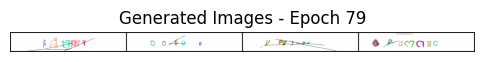

[79/200][0/157]	Loss_D: 0.0690	Loss_G: 4.6797	D(x): 0.9767	D(G(z)): 0.0418 / 0.0430
[79/200][50/157]	Loss_D: 0.0221	Loss_G: 4.7014	D(x): 0.9960	D(G(z)): 0.0176 / 0.0338
[79/200][100/157]	Loss_D: 0.0573	Loss_G: 4.3830	D(x): 0.9881	D(G(z)): 0.0422 / 0.0544
[79/200][150/157]	Loss_D: 0.0924	Loss_G: 5.4354	D(x): 0.9758	D(G(z)): 0.0578 / 0.0244


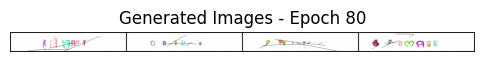

[80/200][0/157]	Loss_D: 0.0447	Loss_G: 6.1236	D(x): 0.9904	D(G(z)): 0.0333 / 0.0131
[80/200][50/157]	Loss_D: 0.0413	Loss_G: 5.6331	D(x): 0.9880	D(G(z)): 0.0271 / 0.0123
[80/200][100/157]	Loss_D: 0.0951	Loss_G: 5.7655	D(x): 0.9822	D(G(z)): 0.0663 / 0.0235
[80/200][150/157]	Loss_D: 0.0616	Loss_G: 5.3078	D(x): 0.9963	D(G(z)): 0.0506 / 0.0242


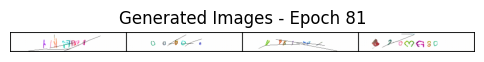

[81/200][0/157]	Loss_D: 0.0161	Loss_G: 5.9252	D(x): 0.9938	D(G(z)): 0.0095 / 0.0144
[81/200][50/157]	Loss_D: 0.3691	Loss_G: 2.3296	D(x): 0.8242	D(G(z)): 0.0858 / 0.2345
[81/200][100/157]	Loss_D: 0.8009	Loss_G: 8.6501	D(x): 0.9939	D(G(z)): 0.4400 / 0.0006
[81/200][150/157]	Loss_D: 0.1561	Loss_G: 4.5690	D(x): 0.9145	D(G(z)): 0.0418 / 0.0650


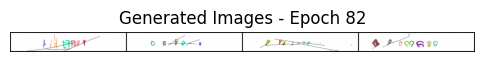

[82/200][0/157]	Loss_D: 0.0456	Loss_G: 5.9286	D(x): 0.9738	D(G(z)): 0.0164 / 0.0103
[82/200][50/157]	Loss_D: 0.1869	Loss_G: 3.3772	D(x): 0.9010	D(G(z)): 0.0658 / 0.1176
[82/200][100/157]	Loss_D: 0.1930	Loss_G: 4.6874	D(x): 0.8975	D(G(z)): 0.0333 / 0.0478
[82/200][150/157]	Loss_D: 0.2053	Loss_G: 4.5344	D(x): 0.9849	D(G(z)): 0.1542 / 0.0404


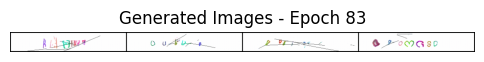

[83/200][0/157]	Loss_D: 0.4836	Loss_G: 3.5558	D(x): 0.9995	D(G(z)): 0.2856 / 0.1138
[83/200][50/157]	Loss_D: 1.3257	Loss_G: 7.1338	D(x): 0.9994	D(G(z)): 0.5936 / 0.0035
[83/200][100/157]	Loss_D: 0.1067	Loss_G: 4.2338	D(x): 0.9148	D(G(z)): 0.0089 / 0.0547
[83/200][150/157]	Loss_D: 0.1902	Loss_G: 5.1373	D(x): 0.9851	D(G(z)): 0.1280 / 0.0311


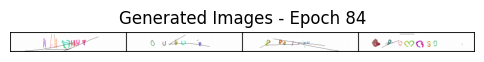

[84/200][0/157]	Loss_D: 0.1066	Loss_G: 6.7812	D(x): 0.9897	D(G(z)): 0.0779 / 0.0100
[84/200][50/157]	Loss_D: 0.0279	Loss_G: 6.3352	D(x): 0.9791	D(G(z)): 0.0057 / 0.0088
[84/200][100/157]	Loss_D: 0.0476	Loss_G: 5.4066	D(x): 0.9900	D(G(z)): 0.0328 / 0.0232
[84/200][150/157]	Loss_D: 0.0963	Loss_G: 5.7306	D(x): 0.9811	D(G(z)): 0.0697 / 0.0179


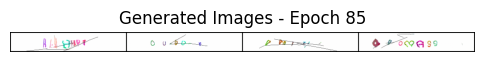

[85/200][0/157]	Loss_D: 0.0528	Loss_G: 5.0095	D(x): 0.9755	D(G(z)): 0.0236 / 0.0330
[85/200][50/157]	Loss_D: 0.0291	Loss_G: 7.5865	D(x): 0.9840	D(G(z)): 0.0123 / 0.0032
[85/200][100/157]	Loss_D: 0.0492	Loss_G: 5.3301	D(x): 0.9947	D(G(z)): 0.0407 / 0.0268
[85/200][150/157]	Loss_D: 0.8270	Loss_G: 1.8334	D(x): 0.5709	D(G(z)): 0.0279 / 0.3526


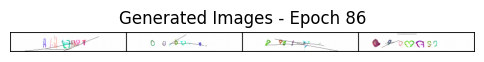

[86/200][0/157]	Loss_D: 0.5033	Loss_G: 1.7258	D(x): 0.6991	D(G(z)): 0.0392 / 0.3489
[86/200][50/157]	Loss_D: 0.1485	Loss_G: 4.7355	D(x): 0.9894	D(G(z)): 0.1158 / 0.0358
[86/200][100/157]	Loss_D: 0.2192	Loss_G: 3.9421	D(x): 0.8319	D(G(z)): 0.0042 / 0.0760
[86/200][150/157]	Loss_D: 1.4961	Loss_G: 9.0945	D(x): 0.9994	D(G(z)): 0.6250 / 0.0007


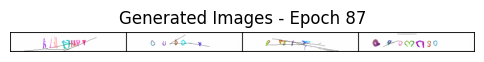

[87/200][0/157]	Loss_D: 0.4920	Loss_G: 1.8165	D(x): 0.7105	D(G(z)): 0.0434 / 0.2904
[87/200][50/157]	Loss_D: 0.0661	Loss_G: 5.5339	D(x): 0.9483	D(G(z)): 0.0091 / 0.0193
[87/200][100/157]	Loss_D: 0.2054	Loss_G: 4.4289	D(x): 0.8421	D(G(z)): 0.0043 / 0.0432
[87/200][150/157]	Loss_D: 0.0677	Loss_G: 4.3905	D(x): 0.9469	D(G(z)): 0.0085 / 0.0432


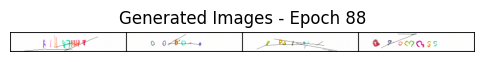

[88/200][0/157]	Loss_D: 0.0910	Loss_G: 4.3648	D(x): 0.9888	D(G(z)): 0.0663 / 0.0418
[88/200][50/157]	Loss_D: 0.0431	Loss_G: 4.0307	D(x): 0.9705	D(G(z)): 0.0106 / 0.0792
[88/200][100/157]	Loss_D: 0.3530	Loss_G: 3.5203	D(x): 0.7469	D(G(z)): 0.0007 / 0.1772
[88/200][150/157]	Loss_D: 0.1116	Loss_G: 5.4814	D(x): 0.9639	D(G(z)): 0.0613 / 0.0189


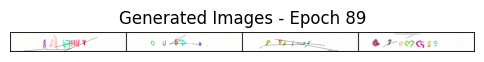

[89/200][0/157]	Loss_D: 0.1157	Loss_G: 6.9453	D(x): 0.9967	D(G(z)): 0.0911 / 0.0053
[89/200][50/157]	Loss_D: 0.0367	Loss_G: 6.4025	D(x): 0.9927	D(G(z)): 0.0272 / 0.0078
[89/200][100/157]	Loss_D: 0.0444	Loss_G: 6.6827	D(x): 0.9885	D(G(z)): 0.0302 / 0.0068
[89/200][150/157]	Loss_D: 0.0600	Loss_G: 5.7707	D(x): 0.9808	D(G(z)): 0.0352 / 0.0171


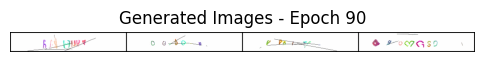

[90/200][0/157]	Loss_D: 0.0709	Loss_G: 5.8581	D(x): 0.9838	D(G(z)): 0.0499 / 0.0187
[90/200][50/157]	Loss_D: 0.1063	Loss_G: 6.5467	D(x): 0.9246	D(G(z)): 0.0103 / 0.0049
[90/200][100/157]	Loss_D: 0.0732	Loss_G: 5.2111	D(x): 0.9956	D(G(z)): 0.0606 / 0.0186
[90/200][150/157]	Loss_D: 0.0811	Loss_G: 5.9267	D(x): 0.9970	D(G(z)): 0.0665 / 0.0098


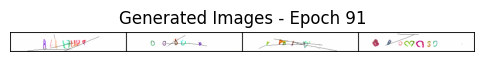

[91/200][0/157]	Loss_D: 0.0834	Loss_G: 5.0322	D(x): 0.9276	D(G(z)): 0.0037 / 0.0271
[91/200][50/157]	Loss_D: 0.3250	Loss_G: 4.2233	D(x): 0.9742	D(G(z)): 0.1798 / 0.0913
[91/200][100/157]	Loss_D: 0.1036	Loss_G: 7.6291	D(x): 0.9763	D(G(z)): 0.0686 / 0.0028
[91/200][150/157]	Loss_D: 0.0877	Loss_G: 4.8915	D(x): 0.9691	D(G(z)): 0.0495 / 0.0270


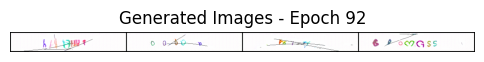

[92/200][0/157]	Loss_D: 0.9590	Loss_G: 6.8146	D(x): 0.9998	D(G(z)): 0.4422 / 0.0119
[92/200][50/157]	Loss_D: 0.4555	Loss_G: 1.1830	D(x): 0.7077	D(G(z)): 0.0265 / 0.4823
[92/200][100/157]	Loss_D: 0.0518	Loss_G: 3.7329	D(x): 0.9773	D(G(z)): 0.0269 / 0.0994
[92/200][150/157]	Loss_D: 0.1525	Loss_G: 4.6219	D(x): 0.9243	D(G(z)): 0.0506 / 0.0268


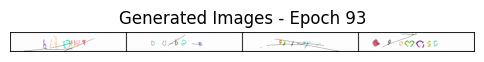

[93/200][0/157]	Loss_D: 0.1220	Loss_G: 4.9795	D(x): 0.9655	D(G(z)): 0.0731 / 0.0410
[93/200][50/157]	Loss_D: 0.1502	Loss_G: 4.2677	D(x): 0.9734	D(G(z)): 0.0876 / 0.0538
[93/200][100/157]	Loss_D: 0.1069	Loss_G: 5.5838	D(x): 0.9906	D(G(z)): 0.0877 / 0.0214
[93/200][150/157]	Loss_D: 0.0432	Loss_G: 6.6550	D(x): 0.9716	D(G(z)): 0.0128 / 0.0146


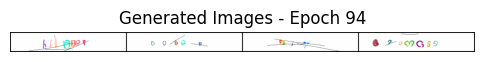

[94/200][0/157]	Loss_D: 0.0889	Loss_G: 5.5262	D(x): 0.9834	D(G(z)): 0.0649 / 0.0303
[94/200][50/157]	Loss_D: 0.0565	Loss_G: 6.6975	D(x): 0.9618	D(G(z)): 0.0150 / 0.0115
[94/200][100/157]	Loss_D: 0.0733	Loss_G: 5.9164	D(x): 0.9616	D(G(z)): 0.0268 / 0.0145
[94/200][150/157]	Loss_D: 0.0879	Loss_G: 4.2483	D(x): 0.9546	D(G(z)): 0.0276 / 0.0646


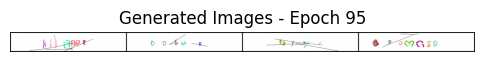

[95/200][0/157]	Loss_D: 0.0703	Loss_G: 4.9150	D(x): 0.9464	D(G(z)): 0.0116 / 0.0406
[95/200][50/157]	Loss_D: 0.0523	Loss_G: 5.7659	D(x): 0.9917	D(G(z)): 0.0412 / 0.0239
[95/200][100/157]	Loss_D: 0.0892	Loss_G: 4.6068	D(x): 0.9378	D(G(z)): 0.0194 / 0.0504
[95/200][150/157]	Loss_D: 0.0654	Loss_G: 5.0341	D(x): 0.9804	D(G(z)): 0.0396 / 0.0252


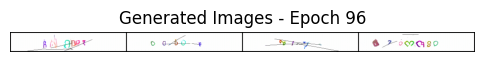

[96/200][0/157]	Loss_D: 0.1484	Loss_G: 4.8943	D(x): 0.8829	D(G(z)): 0.0032 / 0.0300
[96/200][50/157]	Loss_D: 0.0665	Loss_G: 6.0723	D(x): 0.9955	D(G(z)): 0.0570 / 0.0154
[96/200][100/157]	Loss_D: 0.1281	Loss_G: 5.1147	D(x): 0.9052	D(G(z)): 0.0147 / 0.0224
[96/200][150/157]	Loss_D: 0.0601	Loss_G: 6.6579	D(x): 0.9727	D(G(z)): 0.0283 / 0.0050


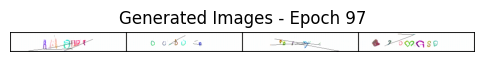

[97/200][0/157]	Loss_D: 0.0442	Loss_G: 4.6550	D(x): 0.9910	D(G(z)): 0.0330 / 0.0463
[97/200][50/157]	Loss_D: 0.0846	Loss_G: 4.9232	D(x): 0.9383	D(G(z)): 0.0160 / 0.0256
[97/200][100/157]	Loss_D: 0.0910	Loss_G: 4.4295	D(x): 0.9385	D(G(z)): 0.0172 / 0.0366
[97/200][150/157]	Loss_D: 0.2454	Loss_G: 2.9207	D(x): 0.9633	D(G(z)): 0.1635 / 0.1554


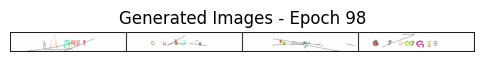

[98/200][0/157]	Loss_D: 0.1356	Loss_G: 4.0920	D(x): 0.9884	D(G(z)): 0.0877 / 0.0814
[98/200][50/157]	Loss_D: 0.1446	Loss_G: 4.5591	D(x): 0.9583	D(G(z)): 0.0830 / 0.0409
[98/200][100/157]	Loss_D: 0.0897	Loss_G: 4.6522	D(x): 0.9395	D(G(z)): 0.0173 / 0.0361
[98/200][150/157]	Loss_D: 0.0647	Loss_G: 4.5125	D(x): 0.9575	D(G(z)): 0.0155 / 0.0266


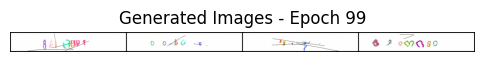

[99/200][0/157]	Loss_D: 0.0546	Loss_G: 6.7303	D(x): 0.9899	D(G(z)): 0.0405 / 0.0084
[99/200][50/157]	Loss_D: 0.0385	Loss_G: 4.7526	D(x): 0.9785	D(G(z)): 0.0146 / 0.0414
[99/200][100/157]	Loss_D: 0.1399	Loss_G: 3.7586	D(x): 0.9528	D(G(z)): 0.0697 / 0.0827
[99/200][150/157]	Loss_D: 0.3427	Loss_G: 1.8501	D(x): 0.7735	D(G(z)): 0.0281 / 0.3283


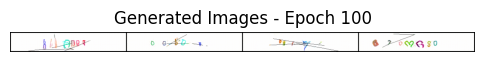

[100/200][0/157]	Loss_D: 0.2643	Loss_G: 5.0554	D(x): 0.9874	D(G(z)): 0.1659 / 0.0211
[100/200][50/157]	Loss_D: 0.0925	Loss_G: 4.6022	D(x): 0.9696	D(G(z)): 0.0536 / 0.0474
[100/200][100/157]	Loss_D: 0.1465	Loss_G: 4.1696	D(x): 0.9967	D(G(z)): 0.1185 / 0.0486
[100/200][150/157]	Loss_D: 0.0443	Loss_G: 5.1748	D(x): 0.9734	D(G(z)): 0.0156 / 0.0297


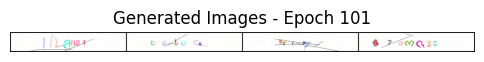

[101/200][0/157]	Loss_D: 0.0497	Loss_G: 5.2623	D(x): 0.9647	D(G(z)): 0.0108 / 0.0221
[101/200][50/157]	Loss_D: 0.0149	Loss_G: 5.0058	D(x): 0.9925	D(G(z)): 0.0072 / 0.0305
[101/200][100/157]	Loss_D: 0.1650	Loss_G: 3.4867	D(x): 0.8778	D(G(z)): 0.0051 / 0.0960
[101/200][150/157]	Loss_D: 0.0687	Loss_G: 5.3832	D(x): 0.9903	D(G(z)): 0.0412 / 0.0177


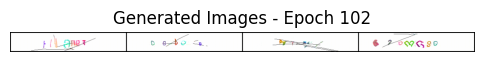

[102/200][0/157]	Loss_D: 0.2431	Loss_G: 7.6075	D(x): 0.9955	D(G(z)): 0.1325 / 0.0028
[102/200][50/157]	Loss_D: 1.3430	Loss_G: 5.1423	D(x): 0.9976	D(G(z)): 0.6101 / 0.0214
[102/200][100/157]	Loss_D: 0.1266	Loss_G: 5.3672	D(x): 0.9783	D(G(z)): 0.0868 / 0.0174
[102/200][150/157]	Loss_D: 0.0687	Loss_G: 4.7235	D(x): 0.9777	D(G(z)): 0.0390 / 0.0529


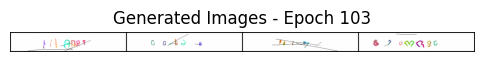

[103/200][0/157]	Loss_D: 0.2647	Loss_G: 6.5402	D(x): 0.9902	D(G(z)): 0.1787 / 0.0173
[103/200][50/157]	Loss_D: 0.0794	Loss_G: 3.8402	D(x): 0.9947	D(G(z)): 0.0625 / 0.1030
[103/200][100/157]	Loss_D: 0.0532	Loss_G: 5.1919	D(x): 0.9640	D(G(z)): 0.0130 / 0.0265
[103/200][150/157]	Loss_D: 0.1183	Loss_G: 5.2632	D(x): 0.9603	D(G(z)): 0.0650 / 0.0135


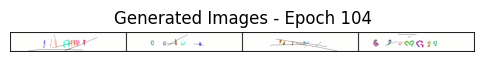

[104/200][0/157]	Loss_D: 0.0562	Loss_G: 5.8779	D(x): 0.9842	D(G(z)): 0.0358 / 0.0161
[104/200][50/157]	Loss_D: 0.0685	Loss_G: 5.5654	D(x): 0.9953	D(G(z)): 0.0568 / 0.0201
[104/200][100/157]	Loss_D: 0.2104	Loss_G: 5.5026	D(x): 0.8620	D(G(z)): 0.0356 / 0.0176
[104/200][150/157]	Loss_D: 0.0705	Loss_G: 5.4440	D(x): 0.9780	D(G(z)): 0.0400 / 0.0141


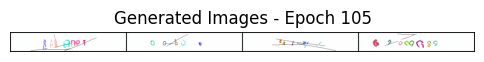

[105/200][0/157]	Loss_D: 0.0728	Loss_G: 4.1272	D(x): 0.9948	D(G(z)): 0.0609 / 0.0705
[105/200][50/157]	Loss_D: 0.0921	Loss_G: 5.5608	D(x): 0.9739	D(G(z)): 0.0568 / 0.0205
[105/200][100/157]	Loss_D: 0.3059	Loss_G: 8.5358	D(x): 0.9894	D(G(z)): 0.1854 / 0.0134
[105/200][150/157]	Loss_D: 0.0281	Loss_G: 5.2525	D(x): 0.9938	D(G(z)): 0.0211 / 0.0266


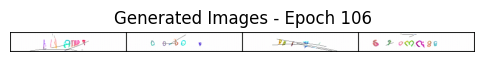

[106/200][0/157]	Loss_D: 0.0429	Loss_G: 5.5280	D(x): 0.9950	D(G(z)): 0.0347 / 0.0256
[106/200][50/157]	Loss_D: 1.8903	Loss_G: 5.3208	D(x): 0.9959	D(G(z)): 0.7134 / 0.0185
[106/200][100/157]	Loss_D: 0.1709	Loss_G: 5.1691	D(x): 0.9226	D(G(z)): 0.0469 / 0.0221
[106/200][150/157]	Loss_D: 0.0908	Loss_G: 4.7358	D(x): 0.9317	D(G(z)): 0.0084 / 0.0339


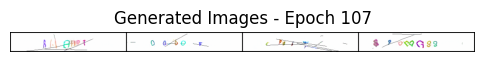

[107/200][0/157]	Loss_D: 0.3418	Loss_G: 5.9068	D(x): 0.9957	D(G(z)): 0.2250 / 0.0256
[107/200][50/157]	Loss_D: 0.0866	Loss_G: 6.6645	D(x): 0.9499	D(G(z)): 0.0240 / 0.0076
[107/200][100/157]	Loss_D: 0.6250	Loss_G: 4.5059	D(x): 0.6366	D(G(z)): 0.0092 / 0.0713
[107/200][150/157]	Loss_D: 0.1111	Loss_G: 5.5549	D(x): 0.9747	D(G(z)): 0.0740 / 0.0229


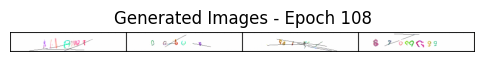

[108/200][0/157]	Loss_D: 0.0645	Loss_G: 6.1113	D(x): 0.9642	D(G(z)): 0.0246 / 0.0130
[108/200][50/157]	Loss_D: 0.1192	Loss_G: 3.7259	D(x): 0.9103	D(G(z)): 0.0116 / 0.1030
[108/200][100/157]	Loss_D: 0.0573	Loss_G: 5.8017	D(x): 0.9693	D(G(z)): 0.0222 / 0.0115
[108/200][150/157]	Loss_D: 0.0778	Loss_G: 6.8485	D(x): 0.9434	D(G(z)): 0.0111 / 0.0059


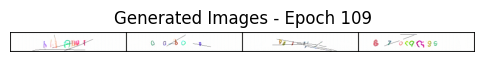

[109/200][0/157]	Loss_D: 0.2014	Loss_G: 4.2287	D(x): 0.8732	D(G(z)): 0.0087 / 0.0498
[109/200][50/157]	Loss_D: 0.0820	Loss_G: 4.2501	D(x): 0.9905	D(G(z)): 0.0655 / 0.0536
[109/200][100/157]	Loss_D: 0.0755	Loss_G: 3.7979	D(x): 0.9660	D(G(z)): 0.0358 / 0.1034
[109/200][150/157]	Loss_D: 0.0856	Loss_G: 4.7577	D(x): 0.9350	D(G(z)): 0.0122 / 0.0406


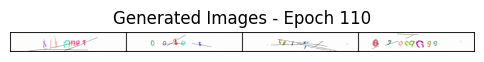

[110/200][0/157]	Loss_D: 0.0468	Loss_G: 5.9365	D(x): 0.9838	D(G(z)): 0.0250 / 0.0102
[110/200][50/157]	Loss_D: 0.1019	Loss_G: 4.9456	D(x): 0.9479	D(G(z)): 0.0404 / 0.0344
[110/200][100/157]	Loss_D: 0.0702	Loss_G: 5.3444	D(x): 0.9401	D(G(z)): 0.0026 / 0.0179
[110/200][150/157]	Loss_D: 0.1000	Loss_G: 6.3210	D(x): 0.9837	D(G(z)): 0.0744 / 0.0077


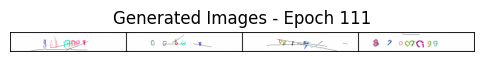

[111/200][0/157]	Loss_D: 0.8263	Loss_G: 11.8253	D(x): 0.9999	D(G(z)): 0.4457 / 0.0001
[111/200][50/157]	Loss_D: 0.0599	Loss_G: 5.0822	D(x): 0.9719	D(G(z)): 0.0271 / 0.0328
[111/200][100/157]	Loss_D: 0.1311	Loss_G: 6.5152	D(x): 0.8928	D(G(z)): 0.0066 / 0.0079
[111/200][150/157]	Loss_D: 0.0383	Loss_G: 4.9748	D(x): 0.9774	D(G(z)): 0.0142 / 0.0356


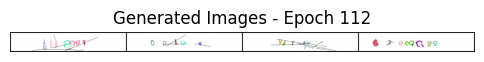

[112/200][0/157]	Loss_D: 0.4374	Loss_G: 7.5768	D(x): 0.9916	D(G(z)): 0.2809 / 0.0027
[112/200][50/157]	Loss_D: 0.6052	Loss_G: 6.9239	D(x): 0.9976	D(G(z)): 0.3584 / 0.0049
[112/200][100/157]	Loss_D: 0.1177	Loss_G: 5.0730	D(x): 0.9828	D(G(z)): 0.0878 / 0.0238
[112/200][150/157]	Loss_D: 0.1498	Loss_G: 4.4869	D(x): 0.8860	D(G(z)): 0.0085 / 0.0357


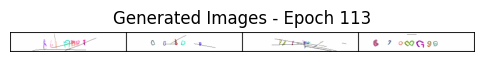

[113/200][0/157]	Loss_D: 0.0977	Loss_G: 4.6842	D(x): 0.9847	D(G(z)): 0.0724 / 0.0489
[113/200][50/157]	Loss_D: 0.0805	Loss_G: 5.0506	D(x): 0.9596	D(G(z)): 0.0297 / 0.0344
[113/200][100/157]	Loss_D: 0.2705	Loss_G: 2.8551	D(x): 0.8832	D(G(z)): 0.1069 / 0.1667
[113/200][150/157]	Loss_D: 0.2167	Loss_G: 4.5743	D(x): 0.8343	D(G(z)): 0.0007 / 0.0564


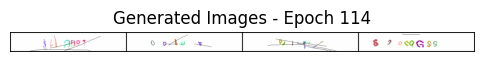

[114/200][0/157]	Loss_D: 0.5901	Loss_G: 7.1921	D(x): 0.9995	D(G(z)): 0.3280 / 0.0068
[114/200][50/157]	Loss_D: 0.1347	Loss_G: 5.0773	D(x): 0.9044	D(G(z)): 0.0208 / 0.0180
[114/200][100/157]	Loss_D: 0.0376	Loss_G: 5.5284	D(x): 0.9772	D(G(z)): 0.0139 / 0.0224
[114/200][150/157]	Loss_D: 0.2505	Loss_G: 6.1608	D(x): 0.9786	D(G(z)): 0.1612 / 0.0075


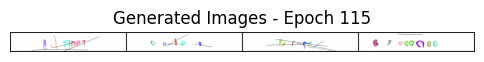

[115/200][0/157]	Loss_D: 1.8654	Loss_G: 14.9245	D(x): 0.9999	D(G(z)): 0.7210 / 0.0000
[115/200][50/157]	Loss_D: 0.0594	Loss_G: 3.9731	D(x): 0.9585	D(G(z)): 0.0119 / 0.0723
[115/200][100/157]	Loss_D: 0.1848	Loss_G: 4.2659	D(x): 0.8712	D(G(z)): 0.0136 / 0.0535
[115/200][150/157]	Loss_D: 0.0807	Loss_G: 6.2842	D(x): 0.9634	D(G(z)): 0.0381 / 0.0154


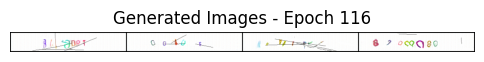

[116/200][0/157]	Loss_D: 0.2105	Loss_G: 4.7451	D(x): 0.9858	D(G(z)): 0.1565 / 0.0319
[116/200][50/157]	Loss_D: 0.0945	Loss_G: 5.7876	D(x): 0.9921	D(G(z)): 0.0752 / 0.0366
[116/200][100/157]	Loss_D: 0.0928	Loss_G: 6.4179	D(x): 0.9359	D(G(z)): 0.0201 / 0.0144
[116/200][150/157]	Loss_D: 0.0343	Loss_G: 4.5565	D(x): 0.9750	D(G(z)): 0.0083 / 0.0582


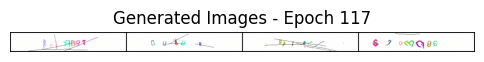

[117/200][0/157]	Loss_D: 0.3938	Loss_G: 8.5680	D(x): 0.9971	D(G(z)): 0.2477 / 0.0009
[117/200][50/157]	Loss_D: 0.0609	Loss_G: 5.2326	D(x): 0.9870	D(G(z)): 0.0422 / 0.0256
[117/200][100/157]	Loss_D: 0.0801	Loss_G: 6.7350	D(x): 0.9670	D(G(z)): 0.0406 / 0.0061
[117/200][150/157]	Loss_D: 0.0554	Loss_G: 5.6983	D(x): 0.9760	D(G(z)): 0.0273 / 0.0156


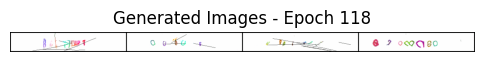

[118/200][0/157]	Loss_D: 0.0478	Loss_G: 5.2064	D(x): 0.9969	D(G(z)): 0.0411 / 0.0339
[118/200][50/157]	Loss_D: 0.0308	Loss_G: 3.9231	D(x): 0.9986	D(G(z)): 0.0272 / 0.0593
[118/200][100/157]	Loss_D: 0.1174	Loss_G: 6.0753	D(x): 0.9652	D(G(z)): 0.0684 / 0.0164
[118/200][150/157]	Loss_D: 0.4331	Loss_G: 2.5864	D(x): 0.7094	D(G(z)): 0.0058 / 0.2421


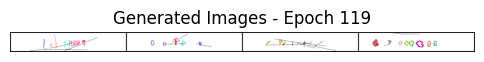

[119/200][0/157]	Loss_D: 0.3594	Loss_G: 4.5161	D(x): 0.9999	D(G(z)): 0.2511 / 0.0472
[119/200][50/157]	Loss_D: 3.4094	Loss_G: 0.3690	D(x): 0.1340	D(G(z)): 0.0011 / 0.7674
[119/200][100/157]	Loss_D: 0.2204	Loss_G: 2.3336	D(x): 0.8586	D(G(z)): 0.0366 / 0.2599
[119/200][150/157]	Loss_D: 0.1985	Loss_G: 4.0312	D(x): 0.8642	D(G(z)): 0.0169 / 0.0619


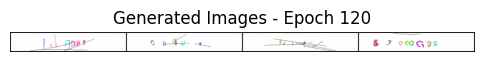

[120/200][0/157]	Loss_D: 0.2269	Loss_G: 5.8346	D(x): 0.9662	D(G(z)): 0.1067 / 0.0172
[120/200][50/157]	Loss_D: 0.2377	Loss_G: 8.2082	D(x): 0.9937	D(G(z)): 0.1718 / 0.0033
[120/200][100/157]	Loss_D: 0.0781	Loss_G: 4.0751	D(x): 0.9933	D(G(z)): 0.0646 / 0.0626
[120/200][150/157]	Loss_D: 0.1073	Loss_G: 3.2880	D(x): 0.9304	D(G(z)): 0.0274 / 0.1336


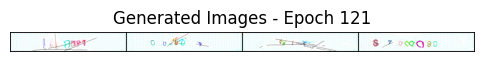

[121/200][0/157]	Loss_D: 0.1409	Loss_G: 5.2998	D(x): 0.9710	D(G(z)): 0.0754 / 0.0433
[121/200][50/157]	Loss_D: 0.9132	Loss_G: 4.2619	D(x): 0.7379	D(G(z)): 0.2341 / 0.0386
[121/200][100/157]	Loss_D: 0.3647	Loss_G: 4.4558	D(x): 0.7427	D(G(z)): 0.0015 / 0.0367
[121/200][150/157]	Loss_D: 0.6028	Loss_G: 6.0680	D(x): 0.9998	D(G(z)): 0.3645 / 0.0079


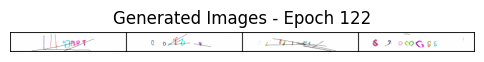

[122/200][0/157]	Loss_D: 0.1265	Loss_G: 3.7489	D(x): 0.9324	D(G(z)): 0.0407 / 0.1052
[122/200][50/157]	Loss_D: 0.0853	Loss_G: 5.2271	D(x): 0.9857	D(G(z)): 0.0625 / 0.0319
[122/200][100/157]	Loss_D: 0.2005	Loss_G: 4.1843	D(x): 0.8568	D(G(z)): 0.0187 / 0.0733
[122/200][150/157]	Loss_D: 0.0384	Loss_G: 4.9596	D(x): 0.9810	D(G(z)): 0.0165 / 0.0373


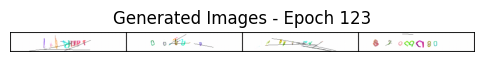

[123/200][0/157]	Loss_D: 0.5849	Loss_G: 7.6996	D(x): 0.9991	D(G(z)): 0.3250 / 0.0037
[123/200][50/157]	Loss_D: 0.0566	Loss_G: 6.6918	D(x): 0.9653	D(G(z)): 0.0163 / 0.0073
[123/200][100/157]	Loss_D: 0.1005	Loss_G: 4.6811	D(x): 0.9218	D(G(z)): 0.0087 / 0.0351
[123/200][150/157]	Loss_D: 0.4828	Loss_G: 4.5749	D(x): 0.9763	D(G(z)): 0.2886 / 0.0505


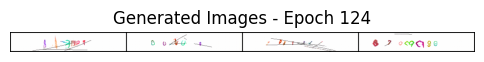

[124/200][0/157]	Loss_D: 0.7108	Loss_G: 6.0940	D(x): 0.9982	D(G(z)): 0.4131 / 0.0148
[124/200][50/157]	Loss_D: 0.4868	Loss_G: 6.3486	D(x): 0.9903	D(G(z)): 0.3112 / 0.0079
[124/200][100/157]	Loss_D: 0.0442	Loss_G: 4.4725	D(x): 0.9956	D(G(z)): 0.0371 / 0.0449
[124/200][150/157]	Loss_D: 0.0837	Loss_G: 5.7109	D(x): 0.9645	D(G(z)): 0.0353 / 0.0204


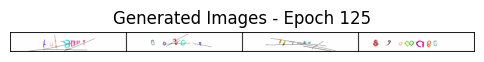

[125/200][0/157]	Loss_D: 0.5871	Loss_G: 8.5833	D(x): 0.9976	D(G(z)): 0.3126 / 0.0026
[125/200][50/157]	Loss_D: 0.1080	Loss_G: 3.8323	D(x): 0.9425	D(G(z)): 0.0316 / 0.0741
[125/200][100/157]	Loss_D: 0.1739	Loss_G: 6.9199	D(x): 0.9945	D(G(z)): 0.1335 / 0.0067
[125/200][150/157]	Loss_D: 0.1457	Loss_G: 7.6203	D(x): 0.9829	D(G(z)): 0.0882 / 0.0035


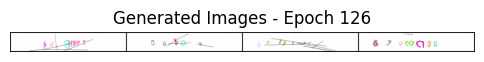

[126/200][0/157]	Loss_D: 0.3382	Loss_G: 6.1530	D(x): 0.9965	D(G(z)): 0.2357 / 0.0165
[126/200][50/157]	Loss_D: 0.1534	Loss_G: 6.5396	D(x): 0.9833	D(G(z)): 0.0907 / 0.0054
[126/200][100/157]	Loss_D: 0.0528	Loss_G: 5.8294	D(x): 0.9733	D(G(z)): 0.0242 / 0.0139
[126/200][150/157]	Loss_D: 0.0677	Loss_G: 4.3030	D(x): 0.9873	D(G(z)): 0.0469 / 0.0663


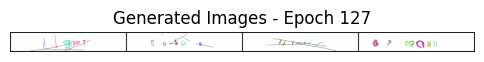

[127/200][0/157]	Loss_D: 0.0356	Loss_G: 5.2273	D(x): 0.9819	D(G(z)): 0.0163 / 0.0246
[127/200][50/157]	Loss_D: 0.0555	Loss_G: 4.7060	D(x): 0.9600	D(G(z)): 0.0104 / 0.0357
[127/200][100/157]	Loss_D: 0.5802	Loss_G: 8.5035	D(x): 0.9934	D(G(z)): 0.3381 / 0.0009
[127/200][150/157]	Loss_D: 0.2343	Loss_G: 6.4943	D(x): 0.8376	D(G(z)): 0.0013 / 0.0071


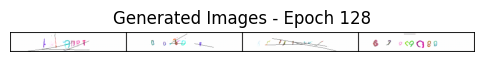

[128/200][0/157]	Loss_D: 0.0649	Loss_G: 6.0832	D(x): 0.9612	D(G(z)): 0.0221 / 0.0200
[128/200][50/157]	Loss_D: 0.3560	Loss_G: 7.1745	D(x): 0.9824	D(G(z)): 0.2216 / 0.0053
[128/200][100/157]	Loss_D: 0.0288	Loss_G: 5.7109	D(x): 0.9932	D(G(z)): 0.0207 / 0.0176
[128/200][150/157]	Loss_D: 0.0246	Loss_G: 4.5145	D(x): 0.9827	D(G(z)): 0.0067 / 0.0508


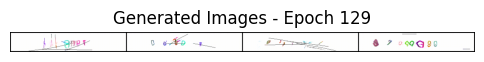

[129/200][0/157]	Loss_D: 0.0828	Loss_G: 5.5937	D(x): 0.9787	D(G(z)): 0.0336 / 0.0181
[129/200][50/157]	Loss_D: 0.1569	Loss_G: 3.3639	D(x): 0.8922	D(G(z)): 0.0133 / 0.0935
[129/200][100/157]	Loss_D: 0.0677	Loss_G: 4.2867	D(x): 0.9589	D(G(z)): 0.0204 / 0.0498
[129/200][150/157]	Loss_D: 0.0199	Loss_G: 5.2434	D(x): 0.9974	D(G(z)): 0.0166 / 0.0202


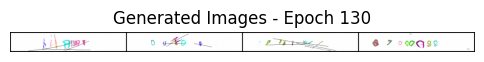

[130/200][0/157]	Loss_D: 0.0701	Loss_G: 5.5275	D(x): 0.9513	D(G(z)): 0.0119 / 0.0243
[130/200][50/157]	Loss_D: 0.1928	Loss_G: 3.8750	D(x): 0.8709	D(G(z)): 0.0036 / 0.0823
[130/200][100/157]	Loss_D: 0.0557	Loss_G: 6.9353	D(x): 0.9910	D(G(z)): 0.0421 / 0.0094
[130/200][150/157]	Loss_D: 0.1137	Loss_G: 4.3051	D(x): 0.9468	D(G(z)): 0.0497 / 0.0682


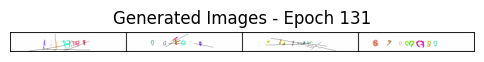

[131/200][0/157]	Loss_D: 3.8793	Loss_G: 9.4131	D(x): 1.0000	D(G(z)): 0.8666 / 0.0023
[131/200][50/157]	Loss_D: 0.1038	Loss_G: 5.5064	D(x): 0.9678	D(G(z)): 0.0505 / 0.0292
[131/200][100/157]	Loss_D: 0.2007	Loss_G: 4.4287	D(x): 0.8764	D(G(z)): 0.0304 / 0.0533
[131/200][150/157]	Loss_D: 0.0541	Loss_G: 6.1719	D(x): 0.9937	D(G(z)): 0.0438 / 0.0124


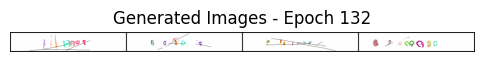

[132/200][0/157]	Loss_D: 0.1146	Loss_G: 4.5308	D(x): 0.9452	D(G(z)): 0.0436 / 0.0345
[132/200][50/157]	Loss_D: 0.0224	Loss_G: 3.7836	D(x): 0.9988	D(G(z)): 0.0205 / 0.0810
[132/200][100/157]	Loss_D: 0.0833	Loss_G: 5.2813	D(x): 0.9514	D(G(z)): 0.0278 / 0.0222
[132/200][150/157]	Loss_D: 0.0526	Loss_G: 6.1134	D(x): 0.9686	D(G(z)): 0.0155 / 0.0088


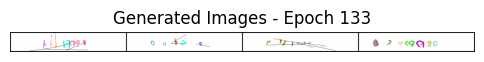

[133/200][0/157]	Loss_D: 0.2775	Loss_G: 1.3418	D(x): 0.8152	D(G(z)): 0.0130 / 0.4881
[133/200][50/157]	Loss_D: 0.2226	Loss_G: 2.7393	D(x): 0.8338	D(G(z)): 0.0033 / 0.1979
[133/200][100/157]	Loss_D: 0.0281	Loss_G: 5.7632	D(x): 0.9910	D(G(z)): 0.0182 / 0.0151
[133/200][150/157]	Loss_D: 0.0393	Loss_G: 8.2131	D(x): 0.9724	D(G(z)): 0.0007 / 0.0248


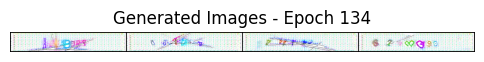

[134/200][0/157]	Loss_D: 0.0000	Loss_G: 46.7291	D(x): 1.0000	D(G(z)): 0.0000 / 0.0000
[134/200][50/157]	Loss_D: 0.4515	Loss_G: 5.7561	D(x): 0.9423	D(G(z)): 0.2462 / 0.0153
[134/200][100/157]	Loss_D: 0.1364	Loss_G: 3.0717	D(x): 0.8993	D(G(z)): 0.0197 / 0.1376
[134/200][150/157]	Loss_D: 0.1473	Loss_G: 3.8103	D(x): 0.9674	D(G(z)): 0.0788 / 0.0910


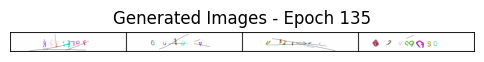

[135/200][0/157]	Loss_D: 0.1124	Loss_G: 4.7498	D(x): 0.9323	D(G(z)): 0.0320 / 0.0349
[135/200][50/157]	Loss_D: 0.0999	Loss_G: 4.7863	D(x): 0.9411	D(G(z)): 0.0311 / 0.0422
[135/200][100/157]	Loss_D: 0.5331	Loss_G: 1.8001	D(x): 0.7312	D(G(z)): 0.0808 / 0.3996
[135/200][150/157]	Loss_D: 0.1331	Loss_G: 6.6978	D(x): 0.9958	D(G(z)): 0.1020 / 0.0069


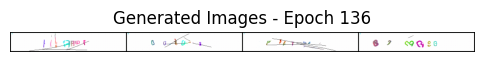

[136/200][0/157]	Loss_D: 0.2443	Loss_G: 3.3988	D(x): 0.8336	D(G(z)): 0.0142 / 0.1248
[136/200][50/157]	Loss_D: 0.0814	Loss_G: 5.0078	D(x): 0.9620	D(G(z)): 0.0388 / 0.0386
[136/200][100/157]	Loss_D: 0.0776	Loss_G: 5.0027	D(x): 0.9785	D(G(z)): 0.0453 / 0.0221
[136/200][150/157]	Loss_D: 0.0411	Loss_G: 5.0513	D(x): 0.9908	D(G(z)): 0.0302 / 0.0275


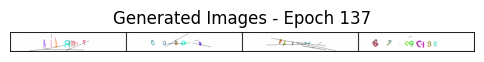

[137/200][0/157]	Loss_D: 1.2002	Loss_G: 10.2459	D(x): 0.9996	D(G(z)): 0.5383 / 0.0004
[137/200][50/157]	Loss_D: 0.3048	Loss_G: 1.9034	D(x): 0.7819	D(G(z)): 0.0088 / 0.4126
[137/200][100/157]	Loss_D: 0.1023	Loss_G: 6.8774	D(x): 0.9920	D(G(z)): 0.0676 / 0.0046
[137/200][150/157]	Loss_D: 0.1173	Loss_G: 4.3321	D(x): 0.9172	D(G(z)): 0.0186 / 0.0496


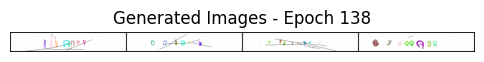

[138/200][0/157]	Loss_D: 0.1145	Loss_G: 4.7813	D(x): 0.9991	D(G(z)): 0.0838 / 0.0660
[138/200][50/157]	Loss_D: 0.0603	Loss_G: 5.9891	D(x): 0.9556	D(G(z)): 0.0118 / 0.0091
[138/200][100/157]	Loss_D: 0.9839	Loss_G: 4.7549	D(x): 0.9978	D(G(z)): 0.5144 / 0.0372
[138/200][150/157]	Loss_D: 0.0835	Loss_G: 4.0552	D(x): 0.9712	D(G(z)): 0.0461 / 0.0791


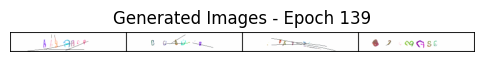

[139/200][0/157]	Loss_D: 4.2013	Loss_G: 12.7278	D(x): 1.0000	D(G(z)): 0.9357 / 0.0001
[139/200][50/157]	Loss_D: 0.0875	Loss_G: 5.0428	D(x): 0.9444	D(G(z)): 0.0213 / 0.0318
[139/200][100/157]	Loss_D: 0.0748	Loss_G: 4.2618	D(x): 0.9966	D(G(z)): 0.0600 / 0.0474
[139/200][150/157]	Loss_D: 0.0874	Loss_G: 5.4378	D(x): 0.9374	D(G(z)): 0.0130 / 0.0176


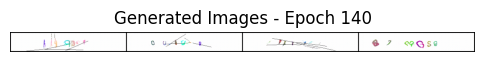

[140/200][0/157]	Loss_D: 0.0807	Loss_G: 5.9558	D(x): 0.9976	D(G(z)): 0.0570 / 0.0160
[140/200][50/157]	Loss_D: 0.0591	Loss_G: 5.3185	D(x): 0.9510	D(G(z)): 0.0052 / 0.0248
[140/200][100/157]	Loss_D: 0.0303	Loss_G: 8.4936	D(x): 0.9910	D(G(z)): 0.0198 / 0.0008
[140/200][150/157]	Loss_D: 0.0545	Loss_G: 6.2943	D(x): 0.9876	D(G(z)): 0.0392 / 0.0066


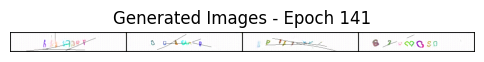

[141/200][0/157]	Loss_D: 0.0431	Loss_G: 5.5830	D(x): 0.9636	D(G(z)): 0.0045 / 0.0150
[141/200][50/157]	Loss_D: 0.0892	Loss_G: 5.4477	D(x): 0.9802	D(G(z)): 0.0590 / 0.0186
[141/200][100/157]	Loss_D: 0.0648	Loss_G: 4.7174	D(x): 0.9904	D(G(z)): 0.0453 / 0.0295
[141/200][150/157]	Loss_D: 0.1544	Loss_G: 7.0610	D(x): 0.9940	D(G(z)): 0.1209 / 0.0025


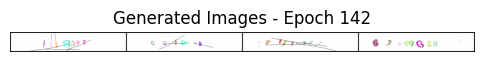

[142/200][0/157]	Loss_D: 0.1372	Loss_G: 3.4363	D(x): 0.9350	D(G(z)): 0.0497 / 0.1211
[142/200][50/157]	Loss_D: 0.7235	Loss_G: 1.9138	D(x): 0.6306	D(G(z)): 0.0165 / 0.3063
[142/200][100/157]	Loss_D: 0.0399	Loss_G: 5.6508	D(x): 0.9905	D(G(z)): 0.0285 / 0.0247
[142/200][150/157]	Loss_D: 0.0526	Loss_G: 5.7889	D(x): 0.9877	D(G(z)): 0.0368 / 0.0165


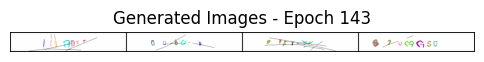

[143/200][0/157]	Loss_D: 0.1364	Loss_G: 6.6608	D(x): 0.9941	D(G(z)): 0.0976 / 0.0118
[143/200][50/157]	Loss_D: 0.1211	Loss_G: 5.8507	D(x): 0.9982	D(G(z)): 0.0960 / 0.0107
[143/200][100/157]	Loss_D: 0.0720	Loss_G: 3.5306	D(x): 0.9750	D(G(z)): 0.0423 / 0.0977
[143/200][150/157]	Loss_D: 0.0719	Loss_G: 5.6953	D(x): 0.9700	D(G(z)): 0.0309 / 0.0268


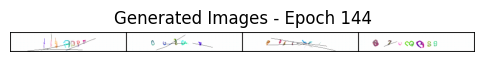

[144/200][0/157]	Loss_D: 0.3150	Loss_G: 1.3080	D(x): 0.7790	D(G(z)): 0.0065 / 0.4614
[144/200][50/157]	Loss_D: 0.0356	Loss_G: 7.5761	D(x): 0.9926	D(G(z)): 0.0243 / 0.0025
[144/200][100/157]	Loss_D: 0.0472	Loss_G: 8.4831	D(x): 0.9619	D(G(z)): 0.0062 / 0.0011
[144/200][150/157]	Loss_D: 0.0607	Loss_G: 5.0210	D(x): 0.9925	D(G(z)): 0.0475 / 0.0262


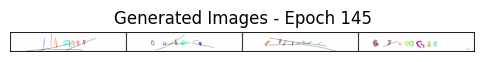

[145/200][0/157]	Loss_D: 0.0454	Loss_G: 5.1344	D(x): 0.9613	D(G(z)): 0.0038 / 0.0175
[145/200][50/157]	Loss_D: 0.0698	Loss_G: 4.9831	D(x): 0.9452	D(G(z)): 0.0070 / 0.0368
[145/200][100/157]	Loss_D: 0.2634	Loss_G: 3.2308	D(x): 0.8189	D(G(z)): 0.0100 / 0.1773
[145/200][150/157]	Loss_D: 0.0727	Loss_G: 4.4323	D(x): 0.9413	D(G(z)): 0.0083 / 0.0603


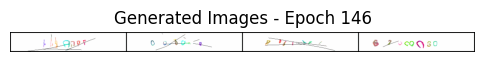

[146/200][0/157]	Loss_D: 0.1630	Loss_G: 6.0819	D(x): 0.9971	D(G(z)): 0.1198 / 0.0146
[146/200][50/157]	Loss_D: 0.0535	Loss_G: 4.5672	D(x): 0.9707	D(G(z)): 0.0209 / 0.0465
[146/200][100/157]	Loss_D: 0.1037	Loss_G: 5.3895	D(x): 0.9108	D(G(z)): 0.0038 / 0.0181
[146/200][150/157]	Loss_D: 0.0304	Loss_G: 6.6305	D(x): 0.9771	D(G(z)): 0.0055 / 0.0130


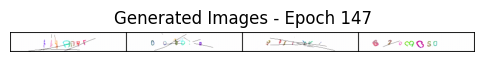

[147/200][0/157]	Loss_D: 0.0298	Loss_G: 6.3611	D(x): 0.9802	D(G(z)): 0.0078 / 0.0149
[147/200][50/157]	Loss_D: 0.0399	Loss_G: 6.5167	D(x): 0.9830	D(G(z)): 0.0203 / 0.0057
[147/200][100/157]	Loss_D: 0.0587	Loss_G: 6.1737	D(x): 0.9935	D(G(z)): 0.0474 / 0.0093
[147/200][150/157]	Loss_D: 0.4892	Loss_G: 7.6227	D(x): 0.9998	D(G(z)): 0.3136 / 0.0026


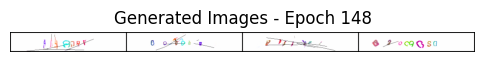

[148/200][0/157]	Loss_D: 1.6604	Loss_G: 14.9716	D(x): 0.9994	D(G(z)): 0.6626 / 0.0000
[148/200][50/157]	Loss_D: 0.1380	Loss_G: 2.9057	D(x): 0.9669	D(G(z)): 0.0873 / 0.1623
[148/200][100/157]	Loss_D: 0.4299	Loss_G: 3.1680	D(x): 0.9871	D(G(z)): 0.2787 / 0.1320
[148/200][150/157]	Loss_D: 0.2874	Loss_G: 6.6294	D(x): 0.9977	D(G(z)): 0.1967 / 0.0064


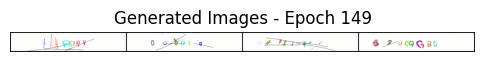

[149/200][0/157]	Loss_D: 0.1547	Loss_G: 4.6648	D(x): 0.8804	D(G(z)): 0.0091 / 0.0441
[149/200][50/157]	Loss_D: 0.0680	Loss_G: 5.0735	D(x): 0.9471	D(G(z)): 0.0094 / 0.0281
[149/200][100/157]	Loss_D: 0.1293	Loss_G: 4.3513	D(x): 0.9916	D(G(z)): 0.0954 / 0.0475
[149/200][150/157]	Loss_D: 0.9235	Loss_G: 1.1954	D(x): 0.5935	D(G(z)): 0.0407 / 0.4881


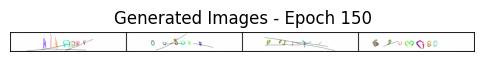

[150/200][0/157]	Loss_D: 0.2284	Loss_G: 3.0545	D(x): 0.9173	D(G(z)): 0.0951 / 0.1374
[150/200][50/157]	Loss_D: 0.0783	Loss_G: 5.9644	D(x): 0.9468	D(G(z)): 0.0191 / 0.0153
[150/200][100/157]	Loss_D: 0.1440	Loss_G: 6.3688	D(x): 0.9976	D(G(z)): 0.1047 / 0.0090
[150/200][150/157]	Loss_D: 0.0683	Loss_G: 5.2119	D(x): 0.9759	D(G(z)): 0.0375 / 0.0179


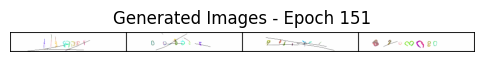

[151/200][0/157]	Loss_D: 0.2131	Loss_G: 4.2558	D(x): 0.9016	D(G(z)): 0.0452 / 0.0463
[151/200][50/157]	Loss_D: 0.0334	Loss_G: 5.5077	D(x): 0.9717	D(G(z)): 0.0033 / 0.0163
[151/200][100/157]	Loss_D: 0.1070	Loss_G: 6.3489	D(x): 0.9322	D(G(z)): 0.0243 / 0.0122
[151/200][150/157]	Loss_D: 0.0249	Loss_G: 5.5629	D(x): 0.9971	D(G(z)): 0.0209 / 0.0176


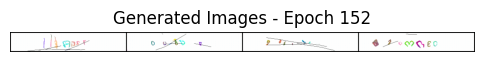

[152/200][0/157]	Loss_D: 0.1263	Loss_G: 4.1022	D(x): 0.9247	D(G(z)): 0.0352 / 0.0884
[152/200][50/157]	Loss_D: 0.1743	Loss_G: 5.8710	D(x): 0.9013	D(G(z)): 0.0494 / 0.0116
[152/200][100/157]	Loss_D: 0.0953	Loss_G: 4.9891	D(x): 0.9723	D(G(z)): 0.0481 / 0.0307
[152/200][150/157]	Loss_D: 0.0428	Loss_G: 7.3014	D(x): 0.9911	D(G(z)): 0.0318 / 0.0035


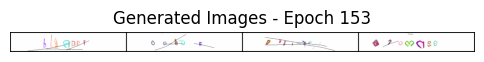

[153/200][0/157]	Loss_D: 0.0410	Loss_G: 4.6833	D(x): 0.9695	D(G(z)): 0.0067 / 0.0335
[153/200][50/157]	Loss_D: 0.0775	Loss_G: 5.5344	D(x): 0.9457	D(G(z)): 0.0160 / 0.0208
[153/200][100/157]	Loss_D: 0.2367	Loss_G: 6.2794	D(x): 0.9537	D(G(z)): 0.1306 / 0.0075
[153/200][150/157]	Loss_D: 0.3976	Loss_G: 5.2376	D(x): 0.7527	D(G(z)): 0.0075 / 0.0484


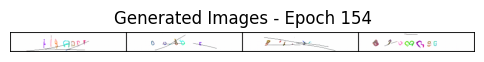

[154/200][0/157]	Loss_D: 0.0882	Loss_G: 4.2348	D(x): 0.9726	D(G(z)): 0.0530 / 0.0532
[154/200][50/157]	Loss_D: 0.0642	Loss_G: 5.0008	D(x): 0.9573	D(G(z)): 0.0158 / 0.0312
[154/200][100/157]	Loss_D: 0.0479	Loss_G: 4.7334	D(x): 0.9900	D(G(z)): 0.0351 / 0.0380
[154/200][150/157]	Loss_D: 0.3110	Loss_G: 3.7743	D(x): 0.7874	D(G(z)): 0.0095 / 0.0838


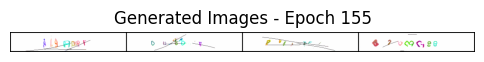

[155/200][0/157]	Loss_D: 0.0603	Loss_G: 6.1389	D(x): 0.9896	D(G(z)): 0.0441 / 0.0107
[155/200][50/157]	Loss_D: 0.0721	Loss_G: 4.2973	D(x): 0.9832	D(G(z)): 0.0412 / 0.0415
[155/200][100/157]	Loss_D: 0.0410	Loss_G: 4.2321	D(x): 0.9732	D(G(z)): 0.0099 / 0.0545
[155/200][150/157]	Loss_D: 1.1828	Loss_G: 3.1207	D(x): 0.4607	D(G(z)): 0.0063 / 0.1034


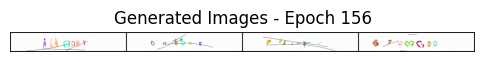

[156/200][0/157]	Loss_D: 0.2500	Loss_G: 3.6602	D(x): 0.9116	D(G(z)): 0.1118 / 0.0910
[156/200][50/157]	Loss_D: 0.1273	Loss_G: 4.6692	D(x): 0.9253	D(G(z)): 0.0255 / 0.0380
[156/200][100/157]	Loss_D: 0.2459	Loss_G: 2.6882	D(x): 0.8291	D(G(z)): 0.0036 / 0.2229
[156/200][150/157]	Loss_D: 0.0284	Loss_G: 6.0871	D(x): 0.9837	D(G(z)): 0.0114 / 0.0107


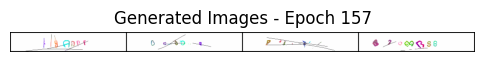

[157/200][0/157]	Loss_D: 0.0162	Loss_G: 7.4145	D(x): 0.9943	D(G(z)): 0.0102 / 0.0052
[157/200][50/157]	Loss_D: 0.2936	Loss_G: 4.1020	D(x): 0.8876	D(G(z)): 0.0965 / 0.0711
[157/200][100/157]	Loss_D: 0.1176	Loss_G: 5.5235	D(x): 0.9799	D(G(z)): 0.0753 / 0.0174
[157/200][150/157]	Loss_D: 0.1298	Loss_G: 4.8757	D(x): 0.9802	D(G(z)): 0.0914 / 0.0331


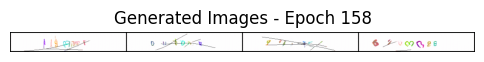

[158/200][0/157]	Loss_D: 0.0797	Loss_G: 4.6954	D(x): 0.9368	D(G(z)): 0.0060 / 0.0380
[158/200][50/157]	Loss_D: 0.1222	Loss_G: 4.9851	D(x): 0.9207	D(G(z)): 0.0242 / 0.0350
[158/200][100/157]	Loss_D: 0.0104	Loss_G: 6.6668	D(x): 0.9955	D(G(z)): 0.0059 / 0.0085
[158/200][150/157]	Loss_D: 0.0521	Loss_G: 6.3795	D(x): 0.9779	D(G(z)): 0.0271 / 0.0048


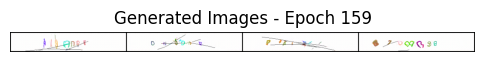

[159/200][0/157]	Loss_D: 1.6382	Loss_G: 12.0772	D(x): 1.0000	D(G(z)): 0.6565 / 0.0000
[159/200][50/157]	Loss_D: 0.0413	Loss_G: 6.8621	D(x): 0.9778	D(G(z)): 0.0149 / 0.0059
[159/200][100/157]	Loss_D: 0.1005	Loss_G: 5.2825	D(x): 0.9260	D(G(z)): 0.0167 / 0.0420
[159/200][150/157]	Loss_D: 0.1566	Loss_G: 5.2175	D(x): 0.9516	D(G(z)): 0.0831 / 0.0231


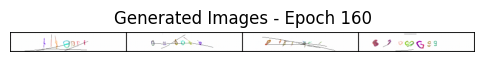

[160/200][0/157]	Loss_D: 2.8246	Loss_G: 10.7077	D(x): 1.0000	D(G(z)): 0.8163 / 0.0001
[160/200][50/157]	Loss_D: 0.0561	Loss_G: 5.1294	D(x): 0.9559	D(G(z)): 0.0090 / 0.0411
[160/200][100/157]	Loss_D: 0.0600	Loss_G: 5.7069	D(x): 0.9733	D(G(z)): 0.0294 / 0.0193
[160/200][150/157]	Loss_D: 0.0375	Loss_G: 4.6181	D(x): 0.9802	D(G(z)): 0.0152 / 0.0687


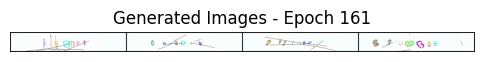

[161/200][0/157]	Loss_D: 0.1445	Loss_G: 5.3202	D(x): 0.9399	D(G(z)): 0.0560 / 0.0277
[161/200][50/157]	Loss_D: 0.0634	Loss_G: 4.3561	D(x): 0.9619	D(G(z)): 0.0218 / 0.0539
[161/200][100/157]	Loss_D: 0.0505	Loss_G: 5.1105	D(x): 0.9753	D(G(z)): 0.0235 / 0.0232
[161/200][150/157]	Loss_D: 0.0557	Loss_G: 6.1864	D(x): 0.9824	D(G(z)): 0.0255 / 0.0136


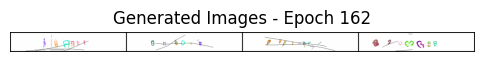

[162/200][0/157]	Loss_D: 0.0764	Loss_G: 5.0160	D(x): 0.9794	D(G(z)): 0.0475 / 0.0229
[162/200][50/157]	Loss_D: 0.1221	Loss_G: 7.0238	D(x): 0.9937	D(G(z)): 0.0872 / 0.0051
[162/200][100/157]	Loss_D: 0.0231	Loss_G: 4.5845	D(x): 0.9984	D(G(z)): 0.0201 / 0.0471
[162/200][150/157]	Loss_D: 0.0678	Loss_G: 6.2139	D(x): 0.9495	D(G(z)): 0.0104 / 0.0095


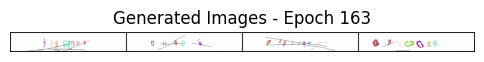

[163/200][0/157]	Loss_D: 0.3610	Loss_G: 6.5615	D(x): 0.9964	D(G(z)): 0.2352 / 0.0147
[163/200][50/157]	Loss_D: 0.1572	Loss_G: 6.6519	D(x): 0.9917	D(G(z)): 0.1179 / 0.0051
[163/200][100/157]	Loss_D: 0.2226	Loss_G: 3.5057	D(x): 0.9550	D(G(z)): 0.1313 / 0.1329
[163/200][150/157]	Loss_D: 0.1449	Loss_G: 5.2435	D(x): 0.9104	D(G(z)): 0.0269 / 0.0422


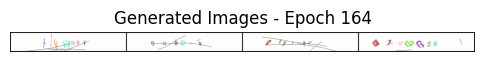

[164/200][0/157]	Loss_D: 3.1951	Loss_G: 11.5358	D(x): 1.0000	D(G(z)): 0.8116 / 0.0002
[164/200][50/157]	Loss_D: 0.0616	Loss_G: 5.4816	D(x): 0.9763	D(G(z)): 0.0335 / 0.0210
[164/200][100/157]	Loss_D: 0.1015	Loss_G: 4.5594	D(x): 0.9194	D(G(z)): 0.0065 / 0.0317
[164/200][150/157]	Loss_D: 0.0190	Loss_G: 7.0925	D(x): 0.9948	D(G(z)): 0.0124 / 0.0048


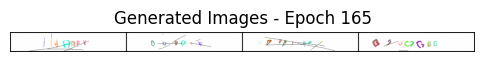

[165/200][0/157]	Loss_D: 0.4498	Loss_G: 8.0505	D(x): 0.9931	D(G(z)): 0.2670 / 0.0030
[165/200][50/157]	Loss_D: 0.0433	Loss_G: 5.5383	D(x): 0.9942	D(G(z)): 0.0349 / 0.0199
[165/200][100/157]	Loss_D: 0.0840	Loss_G: 6.2915	D(x): 0.9587	D(G(z)): 0.0338 / 0.0067
[165/200][150/157]	Loss_D: 0.1685	Loss_G: 3.8391	D(x): 0.8661	D(G(z)): 0.0047 / 0.0785


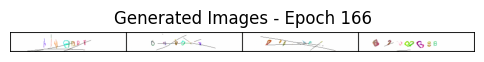

[166/200][0/157]	Loss_D: 0.0822	Loss_G: 5.1389	D(x): 0.9939	D(G(z)): 0.0649 / 0.0270
[166/200][50/157]	Loss_D: 0.0180	Loss_G: 5.4647	D(x): 0.9901	D(G(z)): 0.0078 / 0.0151
[166/200][100/157]	Loss_D: 0.5495	Loss_G: 7.8457	D(x): 0.9760	D(G(z)): 0.2796 / 0.0031
[166/200][150/157]	Loss_D: 0.1213	Loss_G: 5.3018	D(x): 0.9359	D(G(z)): 0.0286 / 0.0407


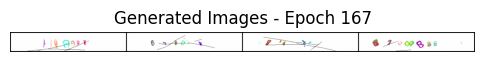

[167/200][0/157]	Loss_D: 0.0824	Loss_G: 4.1926	D(x): 0.9643	D(G(z)): 0.0355 / 0.0742
[167/200][50/157]	Loss_D: 0.0880	Loss_G: 5.9783	D(x): 0.9810	D(G(z)): 0.0490 / 0.0126
[167/200][100/157]	Loss_D: 0.0170	Loss_G: 7.6680	D(x): 0.9922	D(G(z)): 0.0088 / 0.0028
[167/200][150/157]	Loss_D: 0.0933	Loss_G: 6.1790	D(x): 0.9274	D(G(z)): 0.0106 / 0.0151


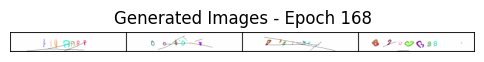

[168/200][0/157]	Loss_D: 0.0693	Loss_G: 6.3673	D(x): 0.9459	D(G(z)): 0.0089 / 0.0081
[168/200][50/157]	Loss_D: 0.0666	Loss_G: 5.2103	D(x): 0.9707	D(G(z)): 0.0311 / 0.0362
[168/200][100/157]	Loss_D: 0.0360	Loss_G: 8.2192	D(x): 0.9692	D(G(z)): 0.0036 / 0.0008
[168/200][150/157]	Loss_D: 0.0735	Loss_G: 4.8339	D(x): 0.9961	D(G(z)): 0.0578 / 0.0421


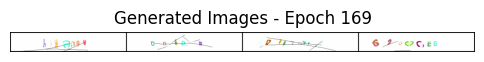

[169/200][0/157]	Loss_D: 0.0590	Loss_G: 6.2092	D(x): 0.9731	D(G(z)): 0.0282 / 0.0069
[169/200][50/157]	Loss_D: 0.0496	Loss_G: 4.9660	D(x): 0.9686	D(G(z)): 0.0147 / 0.0454
[169/200][100/157]	Loss_D: 0.0582	Loss_G: 5.2226	D(x): 0.9626	D(G(z)): 0.0144 / 0.0392
[169/200][150/157]	Loss_D: 0.1575	Loss_G: 4.8904	D(x): 0.8709	D(G(z)): 0.0020 / 0.0399


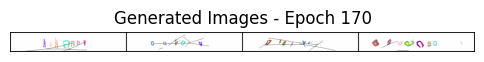

[170/200][0/157]	Loss_D: 0.0418	Loss_G: 7.2179	D(x): 0.9856	D(G(z)): 0.0247 / 0.0031
[170/200][50/157]	Loss_D: 0.2051	Loss_G: 4.6067	D(x): 0.8891	D(G(z)): 0.0379 / 0.0460
[170/200][100/157]	Loss_D: 0.0343	Loss_G: 4.7306	D(x): 0.9799	D(G(z)): 0.0128 / 0.0458
[170/200][150/157]	Loss_D: 3.0891	Loss_G: 21.7674	D(x): 1.0000	D(G(z)): 0.8275 / 0.0000


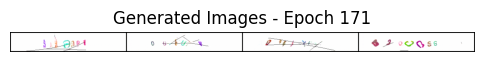

[171/200][0/157]	Loss_D: 4.1647	Loss_G: 0.5706	D(x): 0.1110	D(G(z)): 0.0056 / 0.7711
[171/200][50/157]	Loss_D: 0.2109	Loss_G: 2.2335	D(x): 0.8571	D(G(z)): 0.0230 / 0.2664
[171/200][100/157]	Loss_D: 0.2532	Loss_G: 7.0272	D(x): 0.9965	D(G(z)): 0.1692 / 0.0049
[171/200][150/157]	Loss_D: 0.0954	Loss_G: 3.4666	D(x): 0.9285	D(G(z)): 0.0140 / 0.1112


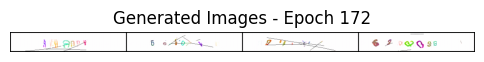

[172/200][0/157]	Loss_D: 0.0982	Loss_G: 7.0675	D(x): 0.9824	D(G(z)): 0.0682 / 0.0045
[172/200][50/157]	Loss_D: 0.0245	Loss_G: 6.6011	D(x): 0.9964	D(G(z)): 0.0202 / 0.0134
[172/200][100/157]	Loss_D: 0.0605	Loss_G: 4.1003	D(x): 0.9866	D(G(z)): 0.0420 / 0.0518
[172/200][150/157]	Loss_D: 0.0726	Loss_G: 5.2917	D(x): 0.9506	D(G(z)): 0.0168 / 0.0318


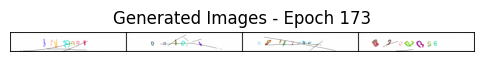

[173/200][0/157]	Loss_D: 0.0414	Loss_G: 5.9460	D(x): 0.9933	D(G(z)): 0.0317 / 0.0094
[173/200][50/157]	Loss_D: 0.0930	Loss_G: 4.7200	D(x): 0.9501	D(G(z)): 0.0286 / 0.0558
[173/200][100/157]	Loss_D: 0.0296	Loss_G: 4.5278	D(x): 0.9835	D(G(z)): 0.0121 / 0.0455
[173/200][150/157]	Loss_D: 0.5358	Loss_G: 1.4096	D(x): 0.7041	D(G(z)): 0.0165 / 0.4105


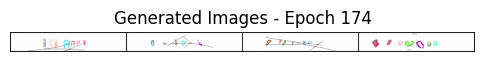

[174/200][0/157]	Loss_D: 0.1225	Loss_G: 3.7801	D(x): 0.9117	D(G(z)): 0.0167 / 0.0992
[174/200][50/157]	Loss_D: 0.2974	Loss_G: 2.9149	D(x): 0.9974	D(G(z)): 0.2053 / 0.1853
[174/200][100/157]	Loss_D: 0.1591	Loss_G: 6.3808	D(x): 0.9892	D(G(z)): 0.1185 / 0.0093
[174/200][150/157]	Loss_D: 0.0924	Loss_G: 3.8251	D(x): 0.9352	D(G(z)): 0.0203 / 0.0806


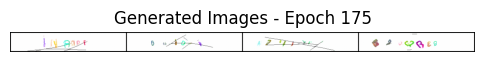

[175/200][0/157]	Loss_D: 0.0483	Loss_G: 6.4992	D(x): 0.9947	D(G(z)): 0.0373 / 0.0069
[175/200][50/157]	Loss_D: 0.1952	Loss_G: 2.9877	D(x): 0.9034	D(G(z)): 0.0655 / 0.1445
[175/200][100/157]	Loss_D: 0.1270	Loss_G: 5.1173	D(x): 0.9837	D(G(z)): 0.0919 / 0.0344
[175/200][150/157]	Loss_D: 0.0452	Loss_G: 4.7116	D(x): 0.9646	D(G(z)): 0.0076 / 0.0418


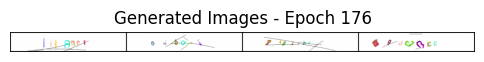

[176/200][0/157]	Loss_D: 0.1023	Loss_G: 4.0051	D(x): 0.9218	D(G(z)): 0.0111 / 0.0692
[176/200][50/157]	Loss_D: 0.0530	Loss_G: 4.8270	D(x): 0.9881	D(G(z)): 0.0356 / 0.0513
[176/200][100/157]	Loss_D: 0.0189	Loss_G: 6.0353	D(x): 0.9852	D(G(z)): 0.0035 / 0.0112
[176/200][150/157]	Loss_D: 0.1612	Loss_G: 4.7699	D(x): 0.8932	D(G(z)): 0.0183 / 0.0429


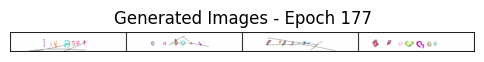

[177/200][0/157]	Loss_D: 0.0250	Loss_G: 5.6675	D(x): 0.9881	D(G(z)): 0.0125 / 0.0129
[177/200][50/157]	Loss_D: 0.1374	Loss_G: 7.2291	D(x): 0.8875	D(G(z)): 0.0024 / 0.0027
[177/200][100/157]	Loss_D: 0.2638	Loss_G: 6.3675	D(x): 0.9969	D(G(z)): 0.1834 / 0.0105
[177/200][150/157]	Loss_D: 0.1904	Loss_G: 5.4684	D(x): 0.9427	D(G(z)): 0.0948 / 0.0154


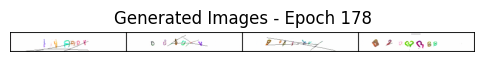

[178/200][0/157]	Loss_D: 0.2320	Loss_G: 4.4081	D(x): 0.9447	D(G(z)): 0.1102 / 0.0936
[178/200][50/157]	Loss_D: 0.0454	Loss_G: 4.7696	D(x): 0.9835	D(G(z)): 0.0265 / 0.0434
[178/200][100/157]	Loss_D: 0.0657	Loss_G: 4.8935	D(x): 0.9631	D(G(z)): 0.0233 / 0.0312
[178/200][150/157]	Loss_D: 0.0878	Loss_G: 3.5635	D(x): 0.9544	D(G(z)): 0.0353 / 0.1074


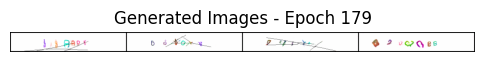

[179/200][0/157]	Loss_D: 0.0385	Loss_G: 7.5812	D(x): 0.9839	D(G(z)): 0.0174 / 0.0024
[179/200][50/157]	Loss_D: 0.1101	Loss_G: 7.5262	D(x): 0.9951	D(G(z)): 0.0675 / 0.0029
[179/200][100/157]	Loss_D: 0.0417	Loss_G: 7.2850	D(x): 0.9632	D(G(z)): 0.0022 / 0.0066
[179/200][150/157]	Loss_D: 0.1645	Loss_G: 4.4437	D(x): 0.9465	D(G(z)): 0.0858 / 0.0628


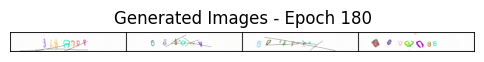

[180/200][0/157]	Loss_D: 0.4186	Loss_G: 4.4296	D(x): 0.7201	D(G(z)): 0.0035 / 0.0606
[180/200][50/157]	Loss_D: 0.1495	Loss_G: 6.3708	D(x): 0.9593	D(G(z)): 0.0771 / 0.0134
[180/200][100/157]	Loss_D: 0.4117	Loss_G: 2.4447	D(x): 0.9012	D(G(z)): 0.2016 / 0.2174
[180/200][150/157]	Loss_D: 0.3600	Loss_G: 1.8188	D(x): 0.7779	D(G(z)): 0.0257 / 0.3569


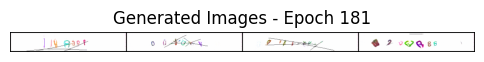

[181/200][0/157]	Loss_D: 0.3854	Loss_G: 2.9497	D(x): 0.8612	D(G(z)): 0.1359 / 0.1536
[181/200][50/157]	Loss_D: 0.1830	Loss_G: 5.5775	D(x): 0.9290	D(G(z)): 0.0617 / 0.0264
[181/200][100/157]	Loss_D: 0.0994	Loss_G: 8.4298	D(x): 0.9170	D(G(z)): 0.0028 / 0.0010
[181/200][150/157]	Loss_D: 0.1565	Loss_G: 5.5928	D(x): 0.9011	D(G(z)): 0.0210 / 0.0305


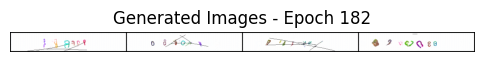

[182/200][0/157]	Loss_D: 0.2139	Loss_G: 1.5781	D(x): 0.8366	D(G(z)): 0.0062 / 0.3762
[182/200][50/157]	Loss_D: 0.1169	Loss_G: 4.6479	D(x): 0.9779	D(G(z)): 0.0643 / 0.0384
[182/200][100/157]	Loss_D: 0.0897	Loss_G: 5.1633	D(x): 0.9339	D(G(z)): 0.0110 / 0.0270
[182/200][150/157]	Loss_D: 0.0992	Loss_G: 4.2768	D(x): 0.9420	D(G(z)): 0.0278 / 0.0557


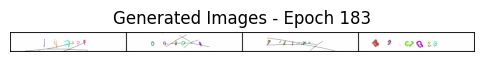

[183/200][0/157]	Loss_D: 0.1155	Loss_G: 4.4437	D(x): 0.9407	D(G(z)): 0.0401 / 0.0716
[183/200][50/157]	Loss_D: 0.1308	Loss_G: 4.9650	D(x): 0.9041	D(G(z)): 0.0122 / 0.0397
[183/200][100/157]	Loss_D: 0.0893	Loss_G: 5.0192	D(x): 0.9817	D(G(z)): 0.0413 / 0.0332
[183/200][150/157]	Loss_D: 0.0209	Loss_G: 4.9326	D(x): 0.9909	D(G(z)): 0.0114 / 0.0375


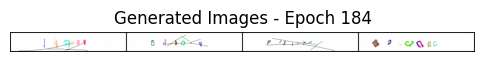

[184/200][0/157]	Loss_D: 0.0645	Loss_G: 5.2624	D(x): 0.9597	D(G(z)): 0.0205 / 0.0210
[184/200][50/157]	Loss_D: 0.0803	Loss_G: 5.9422	D(x): 0.9547	D(G(z)): 0.0308 / 0.0193
[184/200][100/157]	Loss_D: 0.1932	Loss_G: 4.5675	D(x): 0.8960	D(G(z)): 0.0387 / 0.0359
[184/200][150/157]	Loss_D: 0.0990	Loss_G: 5.4702	D(x): 0.9512	D(G(z)): 0.0379 / 0.0452


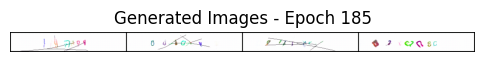

[185/200][0/157]	Loss_D: 0.1999	Loss_G: 4.5677	D(x): 0.9065	D(G(z)): 0.0424 / 0.0659
[185/200][50/157]	Loss_D: 0.0747	Loss_G: 5.3584	D(x): 0.9685	D(G(z)): 0.0385 / 0.0284
[185/200][100/157]	Loss_D: 0.1160	Loss_G: 3.9686	D(x): 0.9960	D(G(z)): 0.0907 / 0.0679
[185/200][150/157]	Loss_D: 0.0507	Loss_G: 5.6021	D(x): 0.9903	D(G(z)): 0.0333 / 0.0159


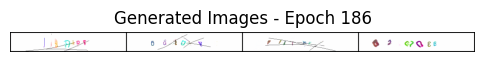

[186/200][0/157]	Loss_D: 0.0632	Loss_G: 6.5230	D(x): 0.9998	D(G(z)): 0.0575 / 0.0070
[186/200][50/157]	Loss_D: 0.1091	Loss_G: 5.0507	D(x): 0.9193	D(G(z)): 0.0147 / 0.0227
[186/200][100/157]	Loss_D: 0.2373	Loss_G: 3.4292	D(x): 0.8267	D(G(z)): 0.0061 / 0.0960
[186/200][150/157]	Loss_D: 0.5692	Loss_G: 8.9229	D(x): 0.9730	D(G(z)): 0.3292 / 0.0009


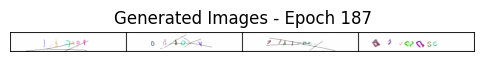

[187/200][0/157]	Loss_D: 0.3851	Loss_G: 2.8877	D(x): 0.7554	D(G(z)): 0.0240 / 0.1938
[187/200][50/157]	Loss_D: 0.4235	Loss_G: 3.1439	D(x): 0.7409	D(G(z)): 0.0010 / 0.1078
[187/200][100/157]	Loss_D: 0.0445	Loss_G: 6.1130	D(x): 0.9851	D(G(z)): 0.0263 / 0.0103
[187/200][150/157]	Loss_D: 0.0383	Loss_G: 5.8323	D(x): 0.9727	D(G(z)): 0.0098 / 0.0281


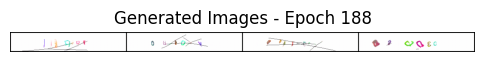

[188/200][0/157]	Loss_D: 0.0497	Loss_G: 5.3131	D(x): 0.9738	D(G(z)): 0.0216 / 0.0369
[188/200][50/157]	Loss_D: 0.0988	Loss_G: 4.6271	D(x): 0.9294	D(G(z)): 0.0193 / 0.0499
[188/200][100/157]	Loss_D: 0.0415	Loss_G: 5.7703	D(x): 0.9907	D(G(z)): 0.0297 / 0.0204
[188/200][150/157]	Loss_D: 0.0749	Loss_G: 4.7136	D(x): 0.9435	D(G(z)): 0.0070 / 0.0455


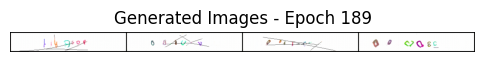

[189/200][0/157]	Loss_D: 1.6723	Loss_G: 0.7477	D(x): 0.3696	D(G(z)): 0.0000 / 0.6800
[189/200][50/157]	Loss_D: 0.0623	Loss_G: 5.5450	D(x): 0.9921	D(G(z)): 0.0483 / 0.0138
[189/200][100/157]	Loss_D: 0.1382	Loss_G: 4.6781	D(x): 0.8936	D(G(z)): 0.0115 / 0.0446
[189/200][150/157]	Loss_D: 0.0750	Loss_G: 6.0665	D(x): 0.9777	D(G(z)): 0.0458 / 0.0085


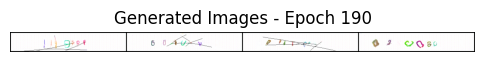

[190/200][0/157]	Loss_D: 0.0708	Loss_G: 4.6466	D(x): 0.9363	D(G(z)): 0.0009 / 0.0403
[190/200][50/157]	Loss_D: 0.0474	Loss_G: 6.2067	D(x): 0.9917	D(G(z)): 0.0352 / 0.0120
[190/200][100/157]	Loss_D: 0.0884	Loss_G: 4.5538	D(x): 0.9417	D(G(z)): 0.0143 / 0.0400
[190/200][150/157]	Loss_D: 7.8237	Loss_G: 0.0000	D(x): 0.0137	D(G(z)): 0.0000 / 1.0000


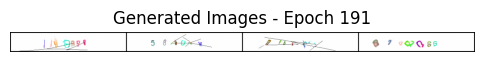

[191/200][0/157]	Loss_D: 4.0094	Loss_G: 5.1713	D(x): 0.9993	D(G(z)): 0.9079 / 0.0375
[191/200][50/157]	Loss_D: 0.1094	Loss_G: 5.8615	D(x): 0.9127	D(G(z)): 0.0029 / 0.0221
[191/200][100/157]	Loss_D: 0.0964	Loss_G: 4.9106	D(x): 0.9779	D(G(z)): 0.0637 / 0.0346
[191/200][150/157]	Loss_D: 0.0940	Loss_G: 5.7266	D(x): 0.9866	D(G(z)): 0.0702 / 0.0118


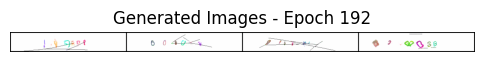

[192/200][0/157]	Loss_D: 0.1326	Loss_G: 5.0698	D(x): 0.9016	D(G(z)): 0.0044 / 0.0378
[192/200][50/157]	Loss_D: 0.1341	Loss_G: 8.6291	D(x): 0.9812	D(G(z)): 0.0874 / 0.0013
[192/200][100/157]	Loss_D: 1.6826	Loss_G: 8.9569	D(x): 0.9991	D(G(z)): 0.6670 / 0.0010
[192/200][150/157]	Loss_D: 0.0335	Loss_G: 5.5276	D(x): 0.9798	D(G(z)): 0.0119 / 0.0127


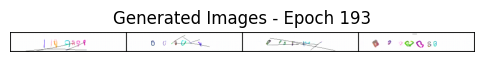

[193/200][0/157]	Loss_D: 0.7324	Loss_G: 8.0691	D(x): 0.9997	D(G(z)): 0.3583 / 0.0029
[193/200][50/157]	Loss_D: 0.0926	Loss_G: 6.7932	D(x): 0.9295	D(G(z)): 0.0102 / 0.0069
[193/200][100/157]	Loss_D: 0.0984	Loss_G: 3.6784	D(x): 0.9930	D(G(z)): 0.0791 / 0.1191
[193/200][150/157]	Loss_D: 0.0456	Loss_G: 5.9525	D(x): 0.9744	D(G(z)): 0.0180 / 0.0175


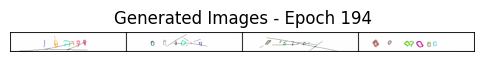

[194/200][0/157]	Loss_D: 9.0879	Loss_G: 16.9431	D(x): 1.0000	D(G(z)): 0.9994 / 0.0000
[194/200][50/157]	Loss_D: 0.5379	Loss_G: 3.1759	D(x): 0.7279	D(G(z)): 0.0552 / 0.1461
[194/200][100/157]	Loss_D: 0.0749	Loss_G: 5.3740	D(x): 0.9736	D(G(z)): 0.0380 / 0.0430
[194/200][150/157]	Loss_D: 0.0455	Loss_G: 5.8340	D(x): 0.9827	D(G(z)): 0.0261 / 0.0119


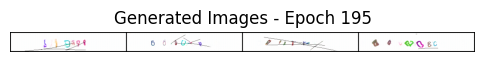

[195/200][0/157]	Loss_D: 0.0554	Loss_G: 6.0247	D(x): 0.9590	D(G(z)): 0.0091 / 0.0253
[195/200][50/157]	Loss_D: 0.2075	Loss_G: 3.2998	D(x): 0.8397	D(G(z)): 0.0074 / 0.1276
[195/200][100/157]	Loss_D: 0.0342	Loss_G: 6.7242	D(x): 0.9760	D(G(z)): 0.0087 / 0.0076
[195/200][150/157]	Loss_D: 0.1475	Loss_G: 4.8884	D(x): 0.9633	D(G(z)): 0.0846 / 0.0342


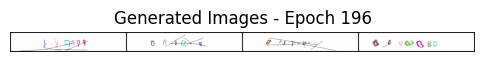

[196/200][0/157]	Loss_D: 0.0550	Loss_G: 5.2896	D(x): 0.9893	D(G(z)): 0.0400 / 0.0274
[196/200][50/157]	Loss_D: 0.4405	Loss_G: 6.1177	D(x): 0.9984	D(G(z)): 0.2761 / 0.0153
[196/200][100/157]	Loss_D: 0.0723	Loss_G: 4.7987	D(x): 0.9704	D(G(z)): 0.0378 / 0.0385
[196/200][150/157]	Loss_D: 0.1571	Loss_G: 5.4398	D(x): 0.9981	D(G(z)): 0.1167 / 0.0212


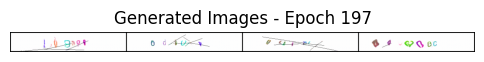

[197/200][0/157]	Loss_D: 0.6937	Loss_G: 7.2435	D(x): 0.9996	D(G(z)): 0.3836 / 0.0043
[197/200][50/157]	Loss_D: 0.2614	Loss_G: 4.1984	D(x): 0.8296	D(G(z)): 0.0275 / 0.0727
[197/200][100/157]	Loss_D: 0.3024	Loss_G: 5.6025	D(x): 0.9911	D(G(z)): 0.2016 / 0.0117
[197/200][150/157]	Loss_D: 0.0907	Loss_G: 5.1544	D(x): 0.9374	D(G(z)): 0.0183 / 0.0180


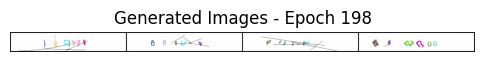

[198/200][0/157]	Loss_D: 0.1039	Loss_G: 3.6790	D(x): 0.9341	D(G(z)): 0.0220 / 0.1006
[198/200][50/157]	Loss_D: 0.0426	Loss_G: 4.7027	D(x): 0.9909	D(G(z)): 0.0310 / 0.0356
[198/200][100/157]	Loss_D: 0.0620	Loss_G: 6.4835	D(x): 0.9890	D(G(z)): 0.0350 / 0.0091
[198/200][150/157]	Loss_D: 0.0372	Loss_G: 5.0694	D(x): 0.9821	D(G(z)): 0.0178 / 0.0339


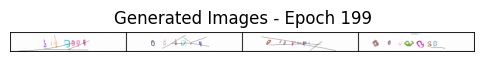

[199/200][0/157]	Loss_D: 0.0579	Loss_G: 6.5898	D(x): 0.9683	D(G(z)): 0.0221 / 0.0063
[199/200][50/157]	Loss_D: 0.0569	Loss_G: 5.4742	D(x): 0.9794	D(G(z)): 0.0207 / 0.0153
[199/200][100/157]	Loss_D: 0.0635	Loss_G: 5.4469	D(x): 0.9492	D(G(z)): 0.0073 / 0.0179
[199/200][150/157]	Loss_D: 0.0377	Loss_G: 5.8995	D(x): 0.9960	D(G(z)): 0.0288 / 0.0199


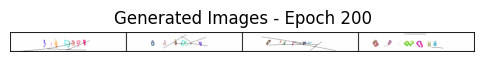

In [35]:
# Training Loop
# Number of training epochs
num_epochs = 200

# Lists to keep track of progress
img_list = []
G_losses = []
D_losses = []
iters = 0

print("Starting Training Loop...")
# For each epoch
for epoch in range(num_epochs):
    # For each batch in the dataloader
    for i, data in enumerate(dataloader, 0):

        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ###########################
        ## Train with all-real batch
        netD.zero_grad()
        # Format batch
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        # Forward pass real batch through D
        output = netD(real_cpu).view(-1)
        # Calculate loss on all-real batch
        errD_real = criterion(output, label)
        # Calculate gradients for D in backward pass
        errD_real.backward()
        D_x = output.mean().item()

        ## Train with all-fake batch
        # Generate batch of latent vectors
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        # Generate fake image batch with G
        fake = netG(noise)
        label.fill_(fake_label)
        # Classify all fake batch with D
        output = netD(fake.detach()).view(-1)
        # Calculate D's loss on the all-fake batch
        errD_fake = criterion(output, label)
        # Calculate the gradients for this batch, accumulated (summed) with previous gradients
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        # Compute error of D as sum over the fake and the real batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ###########################
        for _ in range(2): #double update
            netG.zero_grad()
            label.fill_(real_label)  # fake labels are real for generator cost
            # Since we just updated D, perform another forward pass of all-fake batch through D
            # Generate new fake images
            noise = torch.randn(b_size, nz, 1, 1, device=device)
            fake = netG(noise)
            output = netD(fake).view(-1)
            # Calculate G's loss based on this output
            errG = criterion(output, label)
            # Calculate gradients for G
            errG.backward()
            D_G_z2 = output.mean().item()
            # Update G
            optimizerG.step()

        # Output training stats
        if i % 50 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                  % (epoch, num_epochs, i, len(dataloader),
                     errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Check how the generator is doing by saving G's output on fixed_noise
        if (iters % 500 == 0) or ((epoch == num_epochs-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1

    # --- Display a generated image after each epoch ---
    with torch.no_grad():
        fake_sample = netG(fixed_noise).detach().cpu()
    plt.figure(figsize=(6,6))
    plt.axis("off")
    plt.title(f"Generated Images - Epoch {epoch+1}")
    plt.imshow(np.transpose(vutils.make_grid(fake_sample[:4], padding=2, normalize=True), (1,2,0)))
    plt.show()

### Plot Training Generator and Discriminator loss

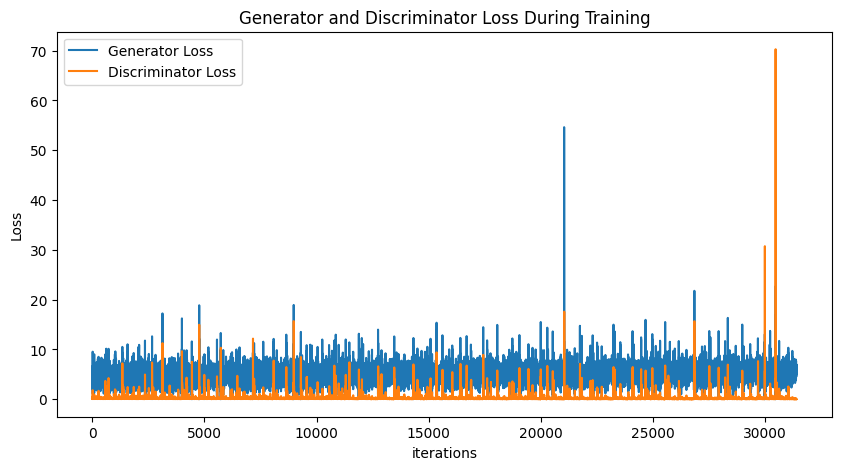

In [37]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses,label="Generator Loss")
plt.plot(D_losses,label="Discriminator Loss")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

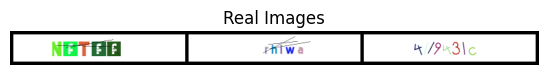

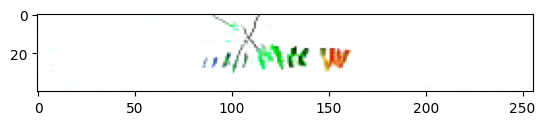

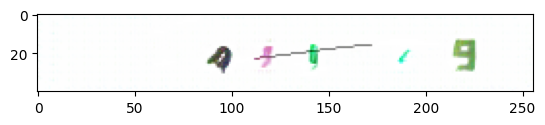

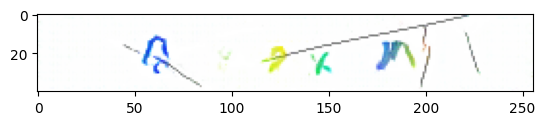

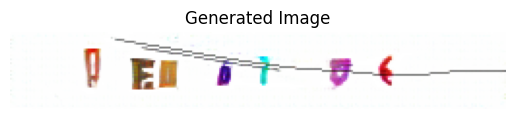

In [31]:
# Grab a batch of real images from the dataloader
real_batch = next(iter(dataloader))

# Plot the real images
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:3], padding=5, normalize=True).cpu(),(1,2,0)))
plt.show()

def generate_fake_image():
    # Make sure the generator is in eval mode
    netG.eval()
    
    # Generate a single latent vector
    noise = torch.randn(1, nz, 1, 1, device=device)
    
    # Generate fake image
    with torch.no_grad():
        fake_img = netG(noise).cpu()  # shape: [1, C, H, W]
    
    # Convert to numpy for plotting
    img = fake_img[0]  # remove batch dimension
    np_img = np.transpose(img, (1, 2, 0))  # [H, W, C]
    
    # Rescale from [-1,1] -> [0,1] for display
    np_img = (np_img + 1) / 2.0
    
    # If grayscale, remove channel dimension
    if np_img.shape[2] == 1:
        np_img = np_img[:, :, 0]
        plt.imshow(np_img, cmap='gray')
    else:
        plt.imshow(np_img)
    
    plt.axis('off')
    plt.title("Generated Image")
    plt.show()

for i in range(3):
    noise = torch.randn(1, nz, 1, 1, device=device)
    fake = netG(noise).detach().cpu()
    plt.imshow(np.transpose((fake[0] + 1)/2, (1,2,0)))
    plt.show()

generate_fake_image()

In [34]:
# Save Generator weights
torch.save(netG.state_dict(), "generator.pth")

# Save Discriminator weights
torch.save(netD.state_dict(), "discriminator.pth")